# ANÁLISIS DE LOS DATOS

In [4]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 178.0 kB/s eta 0:00:00m eta 0:00:010:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kagglehub]━ 3/4 [kagglehub]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')
import kagglehub

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120
})

path = "/home/Beristain/Documentos/IPN/web-traffic-time-series-forecasting"

df = pd.read_csv(path + "/train_1.csv")

print(f"Dimensiones del dataset: {df.shape}")
print(f"Páginas (series): {df.shape[0]:,}")
print(f"Columnas (1 nombre + {df.shape[1]-1} fechas): {df.shape[1]}")
print(f"\nPrimeras columnas: {df.columns[:5].tolist()}")
print(f"Últimas columnas:  {df.columns[-5:].tolist()}")
print(f"\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Dimensiones del dataset: (145063, 551)
Páginas (series): 145,063
Columnas (1 nombre + 550 fechas): 551

Primeras columnas: ['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04']
Últimas columnas:  ['2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31']

Memoria utilizada: 0.65 GB


Distribución por idioma:
language
en         24108
ja         20431
de         18547
fr         17802
zh         17229
ru         15022
es         14069
commons    10555
unknown     7300
Name: count, dtype: int64

Distribución por tipo de acceso:
access
all-access    74315
mobile-web    35939
desktop       34809
Name: count, dtype: int64

Distribución por tipo de agente:
agent
all-agents    110150
spider         34913
Name: count, dtype: int64
Periodo: 2015-07-01 a 2016-12-31
Total de días: 550
Rango de tráfico diario: 127.2M - 316.9M visitas


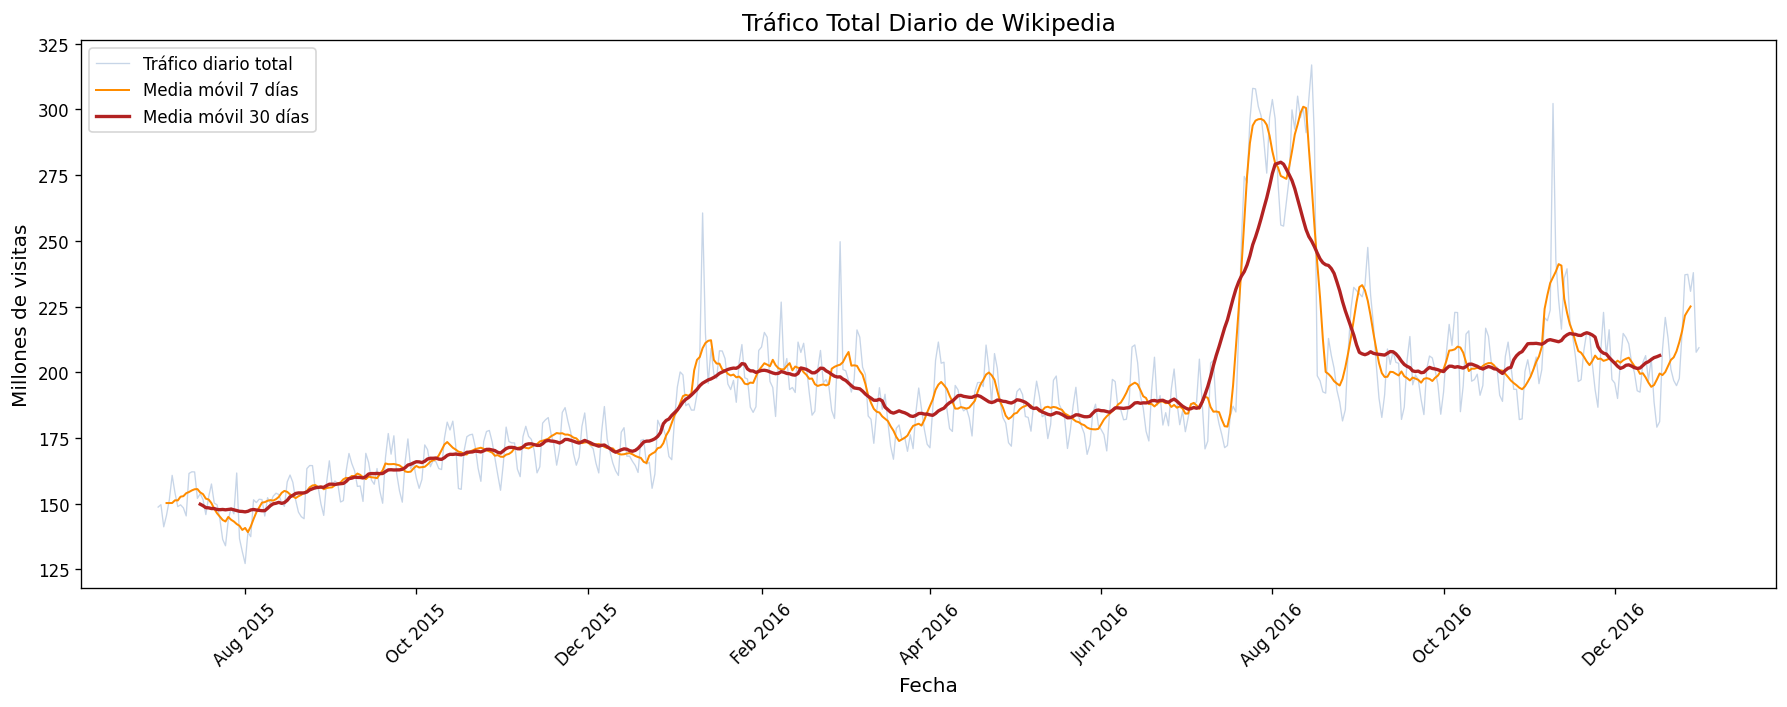

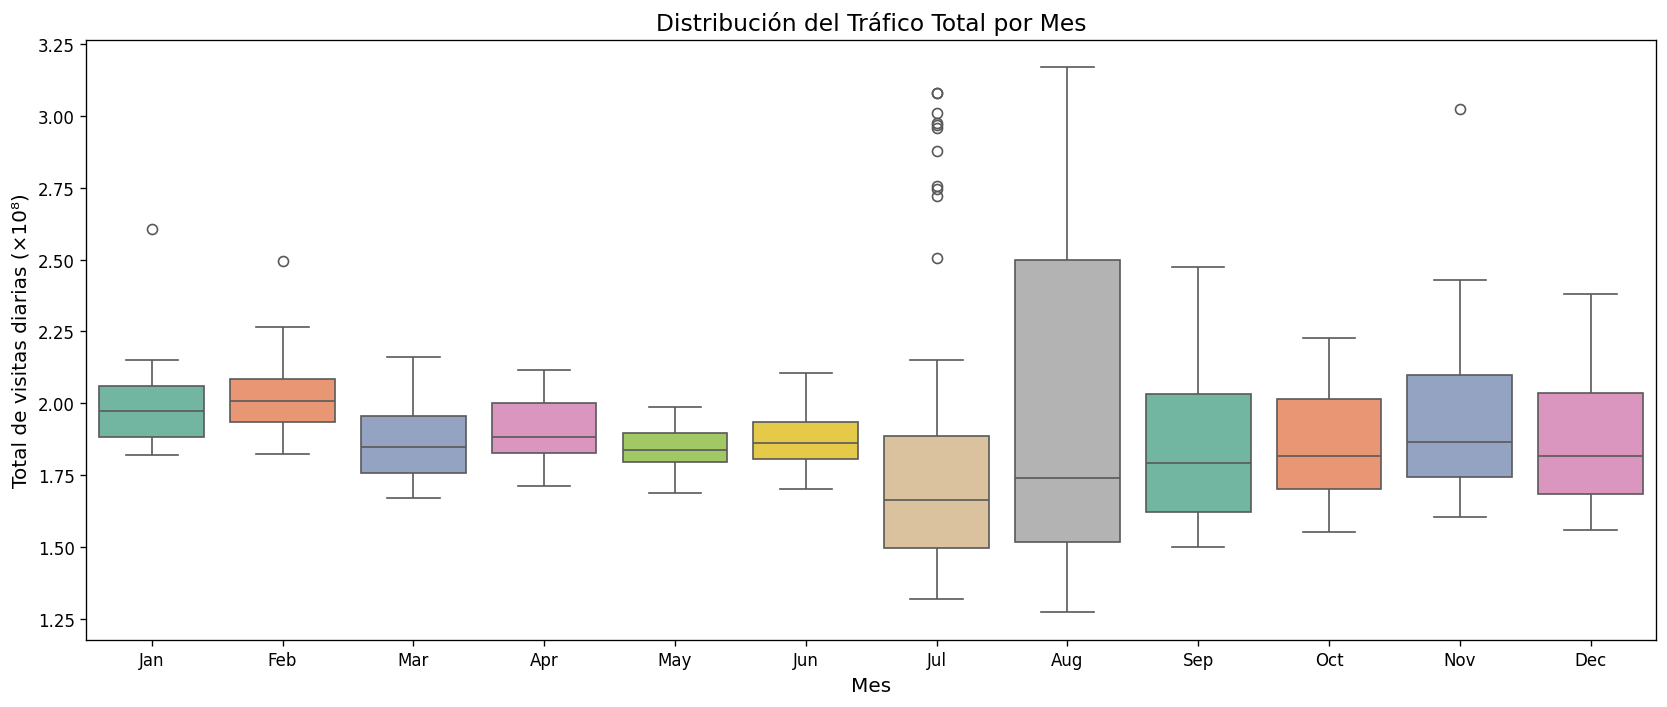

In [8]:
def parse_page_name(page_name):
    """
    Extrae idioma, tipo de acceso y tipo de agente del nombre de la página.
    Formato: Nombre_del_Artículo_xx.wikipedia.org_tipo_acceso_agente
    """
    parts = page_name.split("_")
    agent = parts[-1]          # 'spider' o 'all-agents'
    access = parts[-2]         # 'all-access', 'desktop', 'mobile-web', 'mobile-app'
    
    # El idioma está en la parte que contiene '.wikipedia.org' o 'commons.wikimedia.org'
    site_part = [p for p in parts if 'wikipedia.org' in p or 'wikimedia.org' in p]
    if site_part:
        lang = site_part[0].split('.')[0]
    else:
        lang = 'unknown'
    
    # El nombre del artículo es todo lo anterior al sitio
    site_idx = page_name.find(site_part[0]) if site_part else len(page_name)
    article = page_name[:site_idx].rstrip('_')
    
    return pd.Series([article, lang, access, agent],
                     index=['article', 'language', 'access', 'agent'])

# Aplicar el parseo
meta = df['Page'].apply(parse_page_name)
print("Distribución por idioma:")
print(meta['language'].value_counts())
print("\nDistribución por tipo de acceso:")
print(meta['access'].value_counts())
print("\nDistribución por tipo de agente:")
print(meta['agent'].value_counts())

date_cols = df.columns[1:]
dates = pd.to_datetime(date_cols)

# Calcular el tráfico total diario (suma de todas las páginas por día)
total_daily = df[date_cols].sum(axis=0)
total_daily.index = dates
total_daily.name = 'total_visits'

# Convertir a DataFrame para facilitar el manejo
ts = total_daily.to_frame()
ts['ma_7'] = ts['total_visits'].rolling(window=7, center=True).mean()
ts['ma_30'] = ts['total_visits'].rolling(window=30, center=True).mean()

print(f"Periodo: {dates.min().date()} a {dates.max().date()}")
print(f"Total de días: {len(dates)}")
print(f"Rango de tráfico diario: {total_daily.min()/1e6:.1f}M - {total_daily.max()/1e6:.1f}M visitas")


fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(ts.index, ts['total_visits'] / 1e6, color='lightsteelblue',
        alpha=0.7, linewidth=0.8, label='Tráfico diario total')
ax.plot(ts.index, ts['ma_7'] / 1e6, color='darkorange',
        linewidth=1.2, label='Media móvil 7 días')
ax.plot(ts.index, ts['ma_30'] / 1e6, color='firebrick',
        linewidth=2.0, label='Media móvil 30 días')

ax.set_title('Tráfico Total Diario de Wikipedia')
ax.set_xlabel('Fecha')
ax.set_ylabel('Millones de visitas')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig1_trafico_total_diario.png', dpi=150, bbox_inches='tight')
plt.show()

ts['month'] = ts.index.month
ts['month_name'] = ts.index.strftime('%b')

# Ordenar meses correctamente
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=ts, x='month_name', y='total_visits', order=month_order,
            palette='Set2', ax=ax)
ax.set_title('Distribución del Tráfico Total por Mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Total de visitas diarias')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e8:.2f}'))
ax.set_ylabel('Total de visitas diarias (×10⁸)')
plt.tight_layout()
plt.savefig('fig2_estacionalidad_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

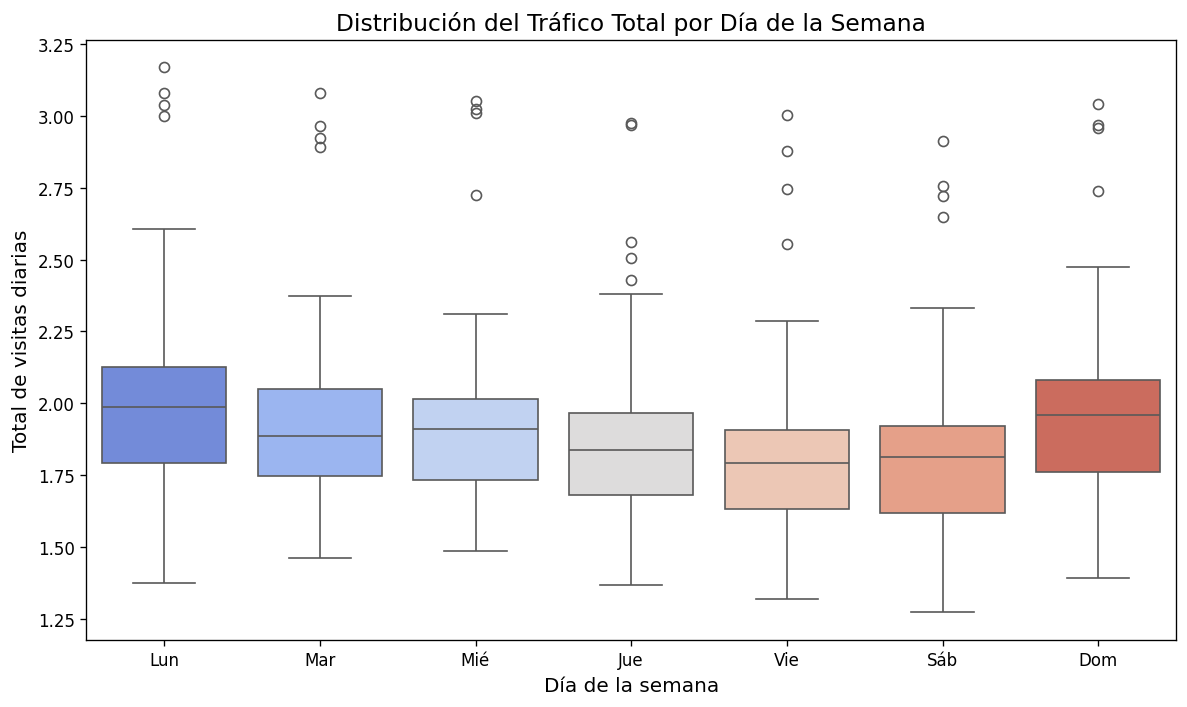

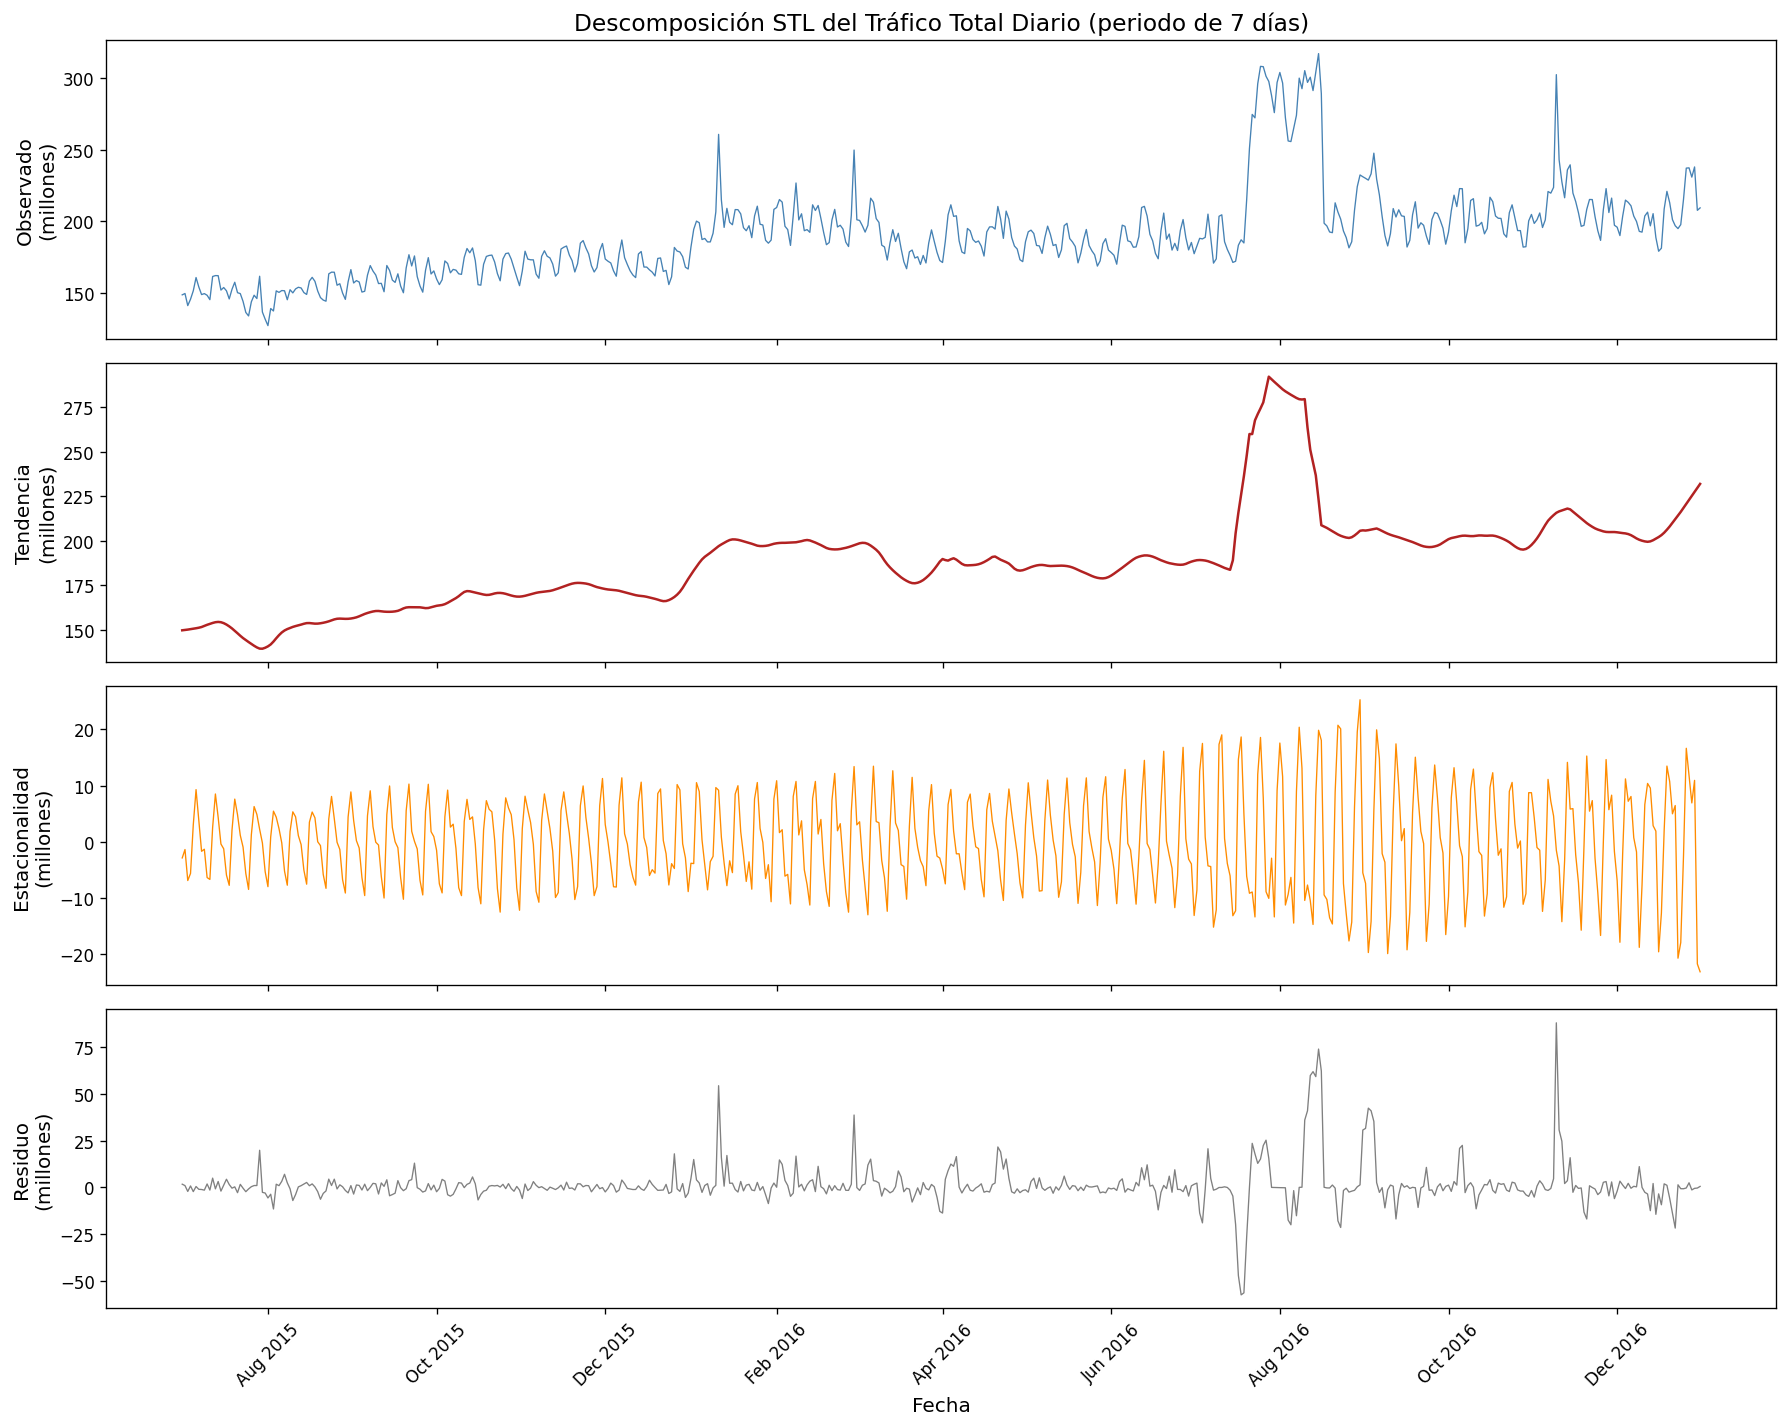


Pruebas de estacionariedad para: Tráfico total diario (nivel)

--- Prueba Aumentada de Dickey-Fuller (ADF) ---
  Estadístico ADF: -2.4366
  p-valor:         0.131663
  Rezagos usados:  14
  Observaciones:   535
  Valor crítico (1%): -3.4426
  Valor crítico (5%): -2.8670
  Valor crítico (10%): -2.5697
 La serie no es estacionaria

--- Prueba KPSS ---
  Estadístico KPSS: 0.1271
  p-valor:          0.0850
  Rezagos usados:   14
  Valor crítico (10%): 0.1190
  Valor crítico (5%): 0.1460
  Valor crítico (2.5%): 0.1760
  Valor crítico (1%): 0.2160
  La serie es estacionaria 

Pruebas de estacionariedad para: Tráfico total diario (1ra diferencia)

--- Prueba Aumentada de Dickey-Fuller (ADF) ---
  Estadístico ADF: -7.8937
  p-valor:         0.000000
  Rezagos usados:  13
  Observaciones:   535
  Valor crítico (1%): -3.4426
  Valor crítico (5%): -2.8670
  Valor crítico (10%): -2.5697
 La serie es estacionaria

--- Prueba KPSS ---
  Estadístico KPSS: 0.0353
  p-valor:          0.1000
  Rezagos 

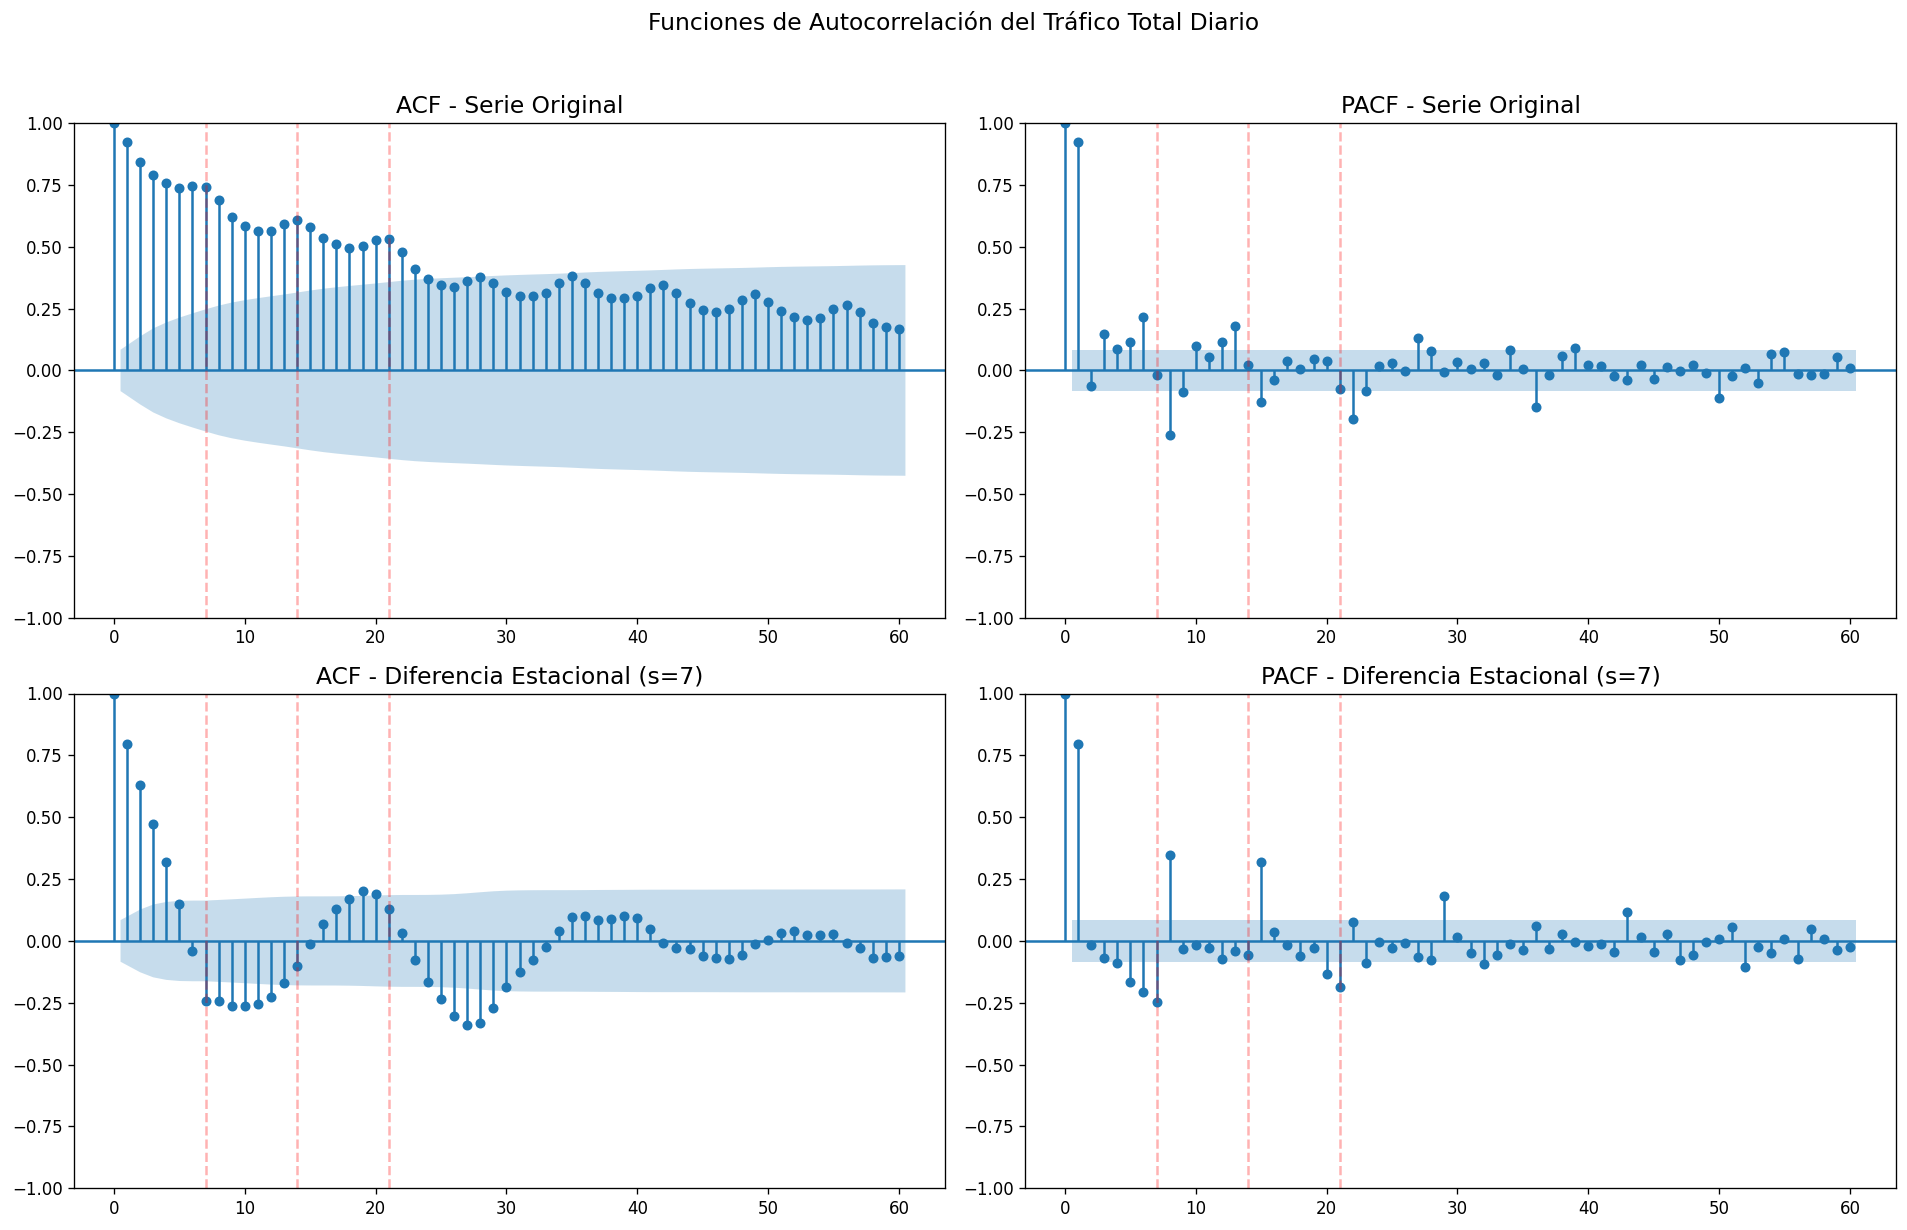

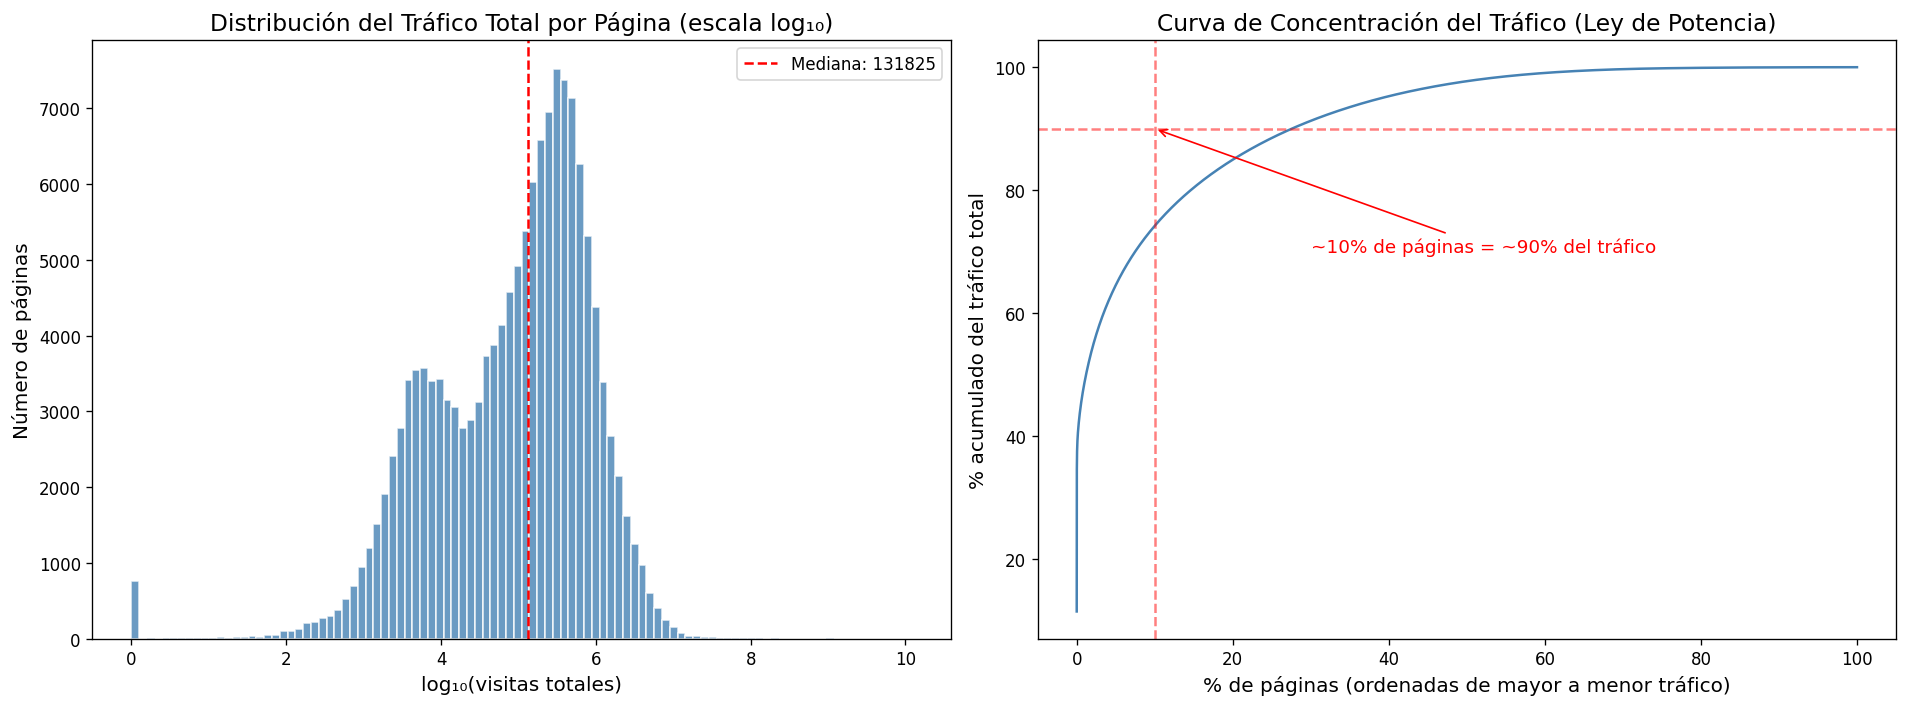


El 10% de páginas más visitadas (14,506 páginas) concentra el 74.2% del tráfico total.


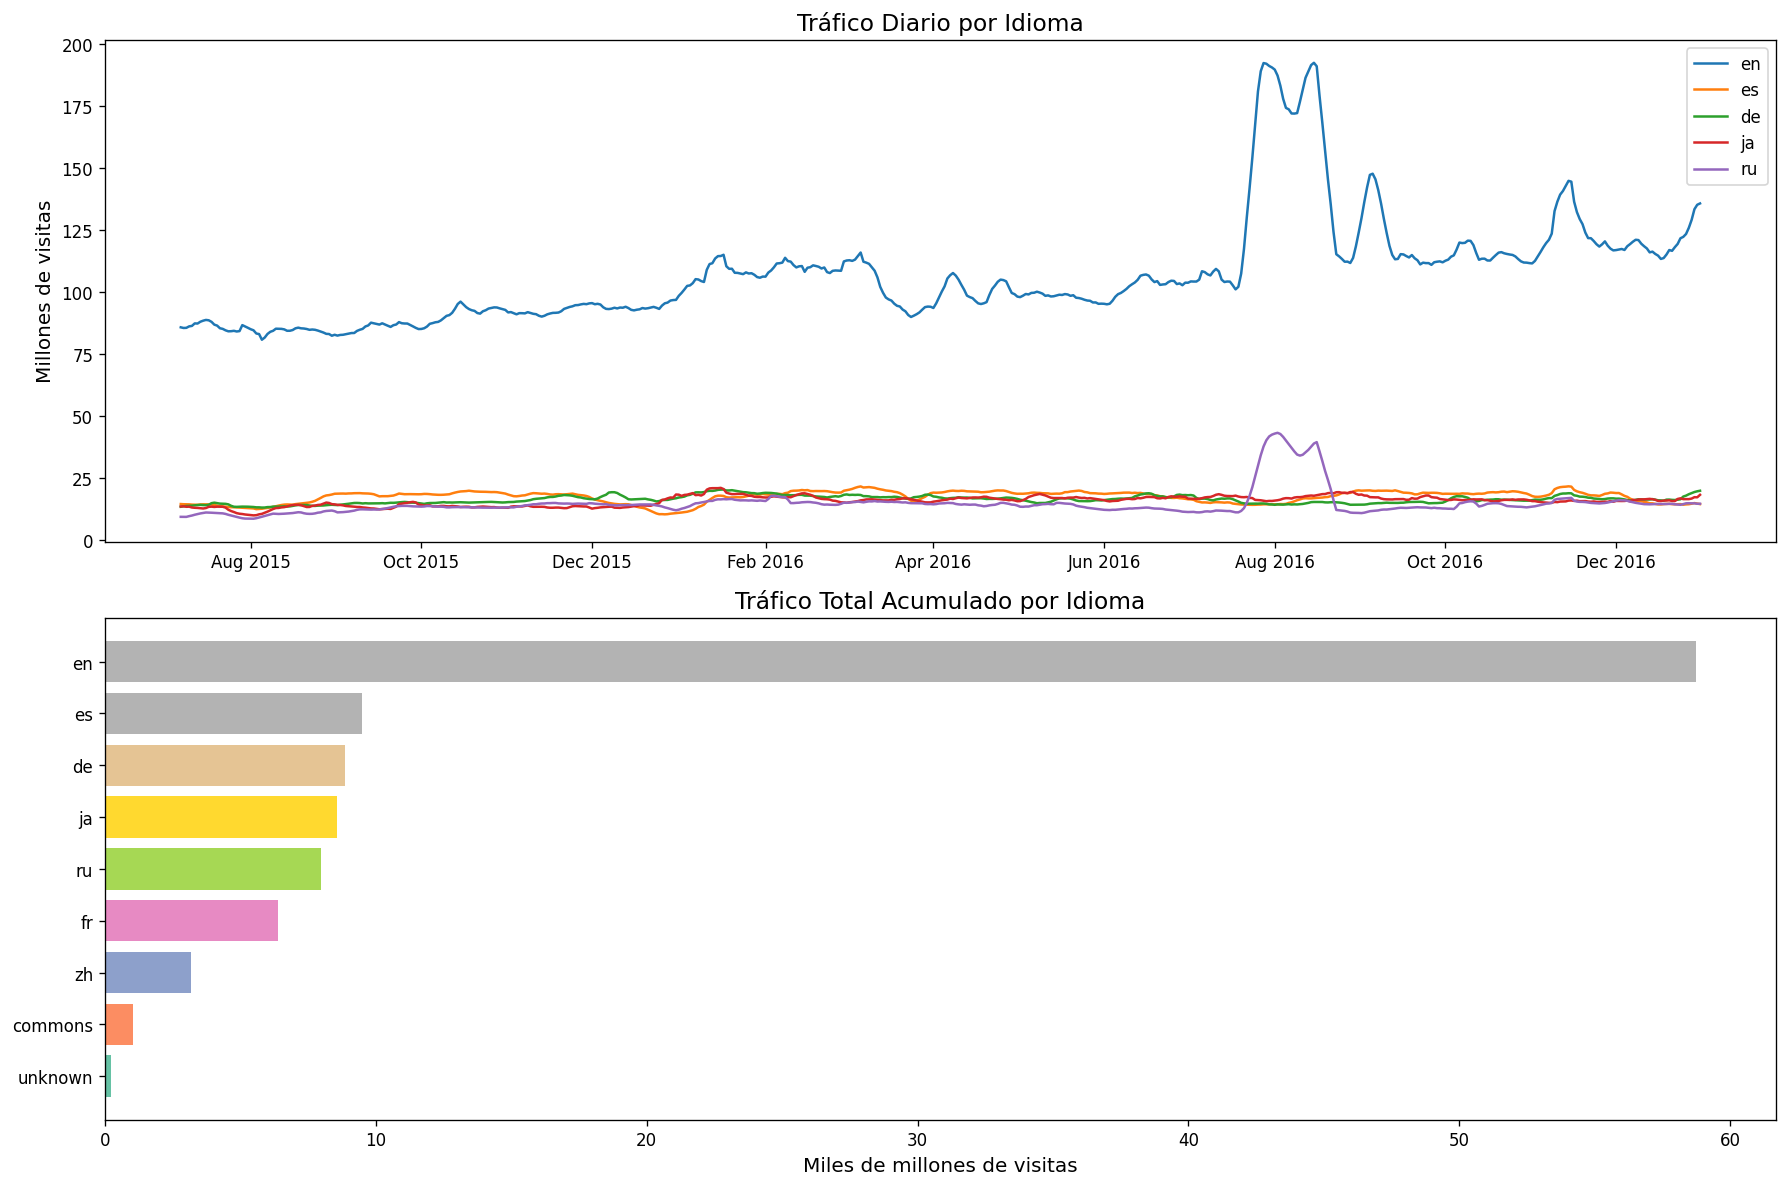

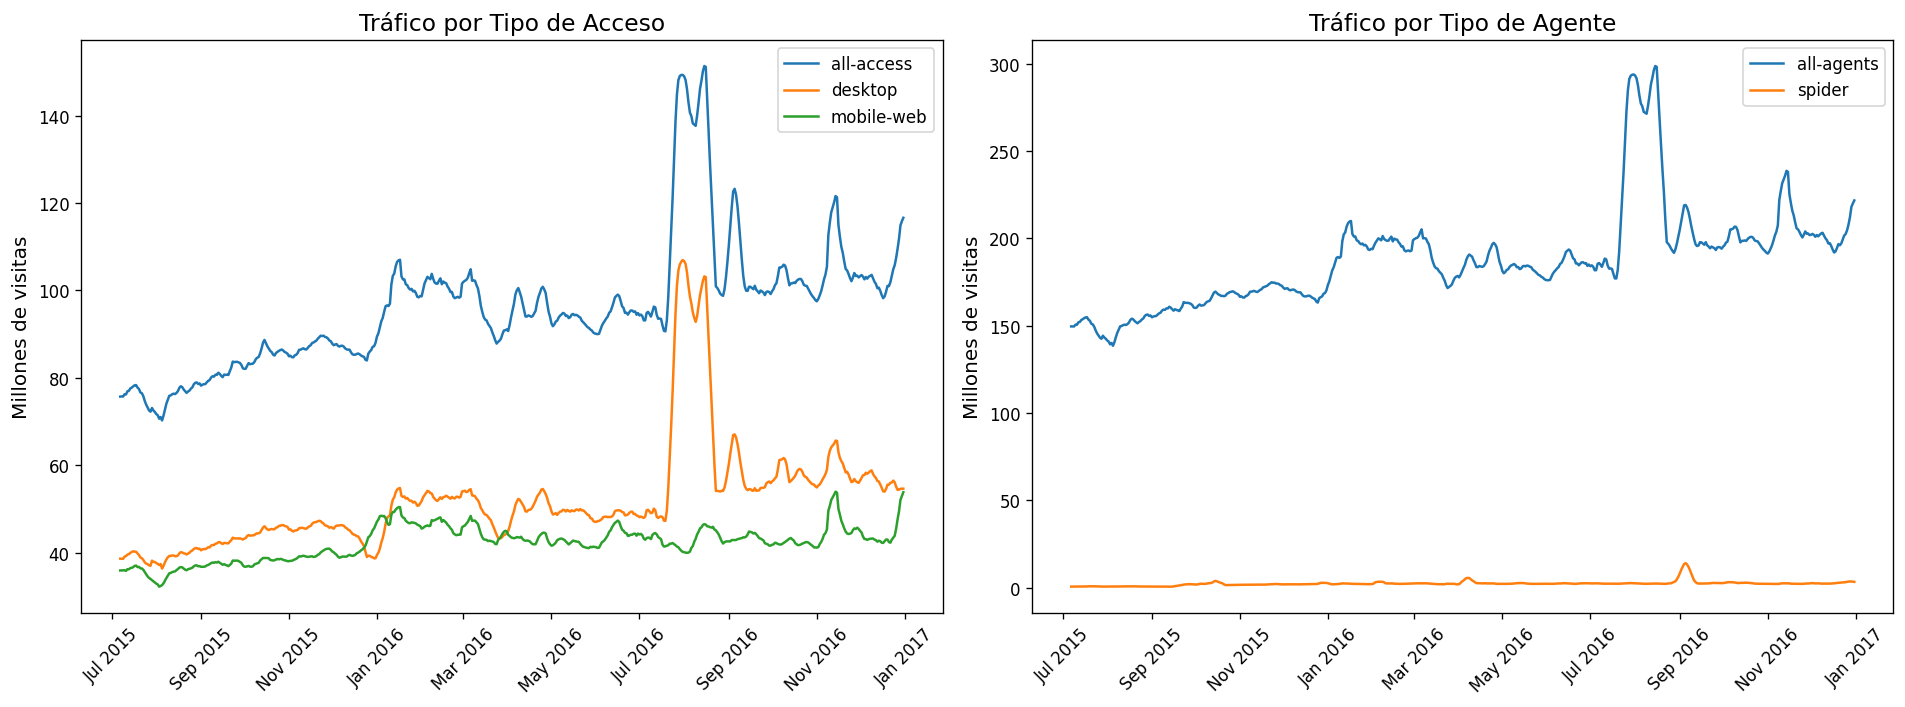

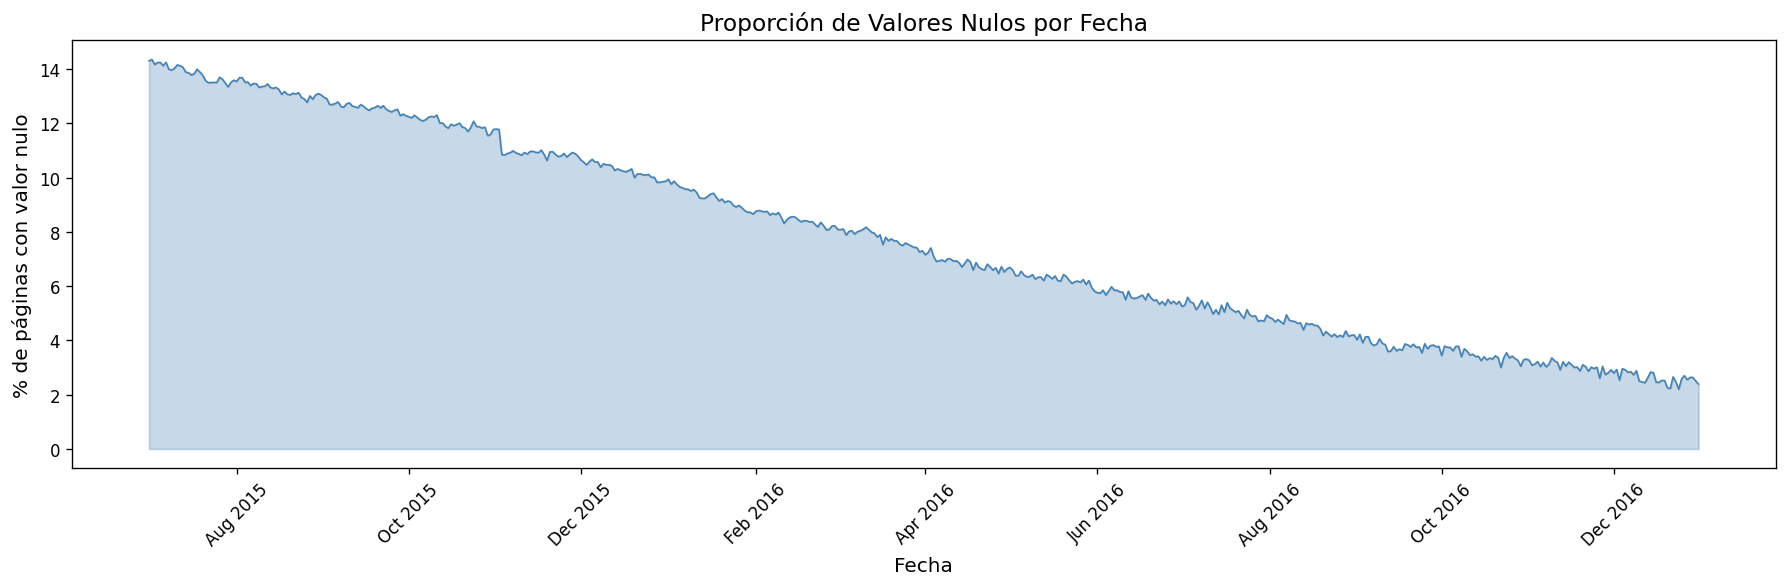

Porcentaje global de nulos: 7.76%
Nulos en el primer mes:     13.87%
Nulos en el último mes:     2.60%


In [9]:
ts['dow'] = ts.index.dayofweek
dow_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=ts, x='dow', y='total_visits', palette='coolwarm', ax=ax)
ax.set_xticklabels(dow_labels)
ax.set_title('Distribución del Tráfico Total por Día de la Semana')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Total de visitas diarias')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e8:.2f}'))
plt.tight_layout()
plt.savefig('fig3_estacionalidad_semanal.png', dpi=150, bbox_inches='tight')
plt.show()

# STL con periodo estacional = 7 (ciclo semanal)
stl = STL(ts['total_visits'], period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

axes[0].plot(ts.index, ts['total_visits'] / 1e6, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Observado\n(millones)')
axes[0].set_title('Descomposición STL del Tráfico Total Diario (periodo de 7 días)')

axes[1].plot(ts.index, result.trend / 1e6, color='firebrick', linewidth=1.5)
axes[1].set_ylabel('Tendencia\n(millones)')

axes[2].plot(ts.index, result.seasonal / 1e6, color='darkorange', linewidth=0.8)
axes[2].set_ylabel('Estacionalidad\n(millones)')

axes[3].plot(ts.index, result.resid / 1e6, color='gray', linewidth=0.8)
axes[3].set_ylabel('Residuo\n(millones)')
axes[3].set_xlabel('Fecha')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig4_descomposicion_stl.png', dpi=150, bbox_inches='tight')
plt.show()

def test_stationarity(series, name="Serie"):
    """Aplica pruebas ADF y KPSS e imprime resultados."""
    print(f"\n{'='*60}")
    print(f"Pruebas de estacionariedad para: {name}")
    print(f"{'='*60}")
    
    # Prueba ADF (H0: la serie tiene raíz unitaria / no es estacionaria)
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n--- Prueba Aumentada de Dickey-Fuller (ADF) ---")
    print(f"  Estadístico ADF: {adf_result[0]:.4f}")
    print(f"  p-valor:         {adf_result[1]:.6f}")
    print(f"  Rezagos usados:  {adf_result[2]}")
    print(f"  Observaciones:   {adf_result[3]}")
    for key, val in adf_result[4].items():
        print(f"  Valor crítico ({key}): {val:.4f}")
    if adf_result[1] < 0.05:
        print(" La serie es estacionaria")
    else:
        print(" La serie no es estacionaria")
    
    # Prueba KPSS (H0: la serie es estacionaria)
    kpss_result = kpss(series.dropna(), regression='ct', nlags='auto')
    print(f"\n--- Prueba KPSS ---")
    print(f"  Estadístico KPSS: {kpss_result[0]:.4f}")
    print(f"  p-valor:          {kpss_result[1]:.4f}")
    print(f"  Rezagos usados:   {kpss_result[2]}")
    for key, val in kpss_result[3].items():
        print(f"  Valor crítico ({key}): {val:.4f}")
    if kpss_result[1] < 0.05:
        print("  La serie no es estacionaria")
    else:
        print("  La serie es estacionaria ")

# Prueba sobre la serie original
test_stationarity(ts['total_visits'], "Tráfico total diario (nivel)")

# Prueba sobre la serie diferenciada (d=1)
ts['diff_1'] = ts['total_visits'].diff(1)
test_stationarity(ts['diff_1'].dropna(), "Tráfico total diario (1ra diferencia)")

# Prueba sobre la serie con diferenciación estacional (D=1, s=7)
ts['diff_7'] = ts['total_visits'].diff(7)
test_stationarity(ts['diff_7'].dropna(), "Tráfico total diario (diferencia estacional s=7)")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF y PACF de la serie original
plot_acf(ts['total_visits'].dropna(), lags=60, ax=axes[0, 0],
         title='ACF - Serie Original')
plot_pacf(ts['total_visits'].dropna(), lags=60, ax=axes[0, 1],
          title='PACF - Serie Original', method='ywm')

# ACF y PACF de la serie diferenciada
plot_acf(ts['diff_7'].dropna(), lags=60, ax=axes[1, 0],
         title='ACF - Diferencia Estacional (s=7)')
plot_pacf(ts['diff_7'].dropna(), lags=60, ax=axes[1, 1],
          title='PACF - Diferencia Estacional (s=7)', method='ywm')

for ax_row in axes:
    for ax in ax_row:
        ax.axvline(x=7, color='red', linestyle='--', alpha=0.3, label='lag 7')
        ax.axvline(x=14, color='red', linestyle='--', alpha=0.3, label='lag 14')
        ax.axvline(x=21, color='red', linestyle='--', alpha=0.3, label='lag 21')

plt.suptitle('Funciones de Autocorrelación del Tráfico Total Diario', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig5_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# Tráfico total por página (suma sobre todas las fechas)
traffic_per_page = df[date_cols].sum(axis=1).sort_values(ascending=False)
traffic_per_page_cum = traffic_per_page.cumsum() / traffic_per_page.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: distribución log del tráfico por página
axes[0].hist(np.log10(traffic_per_page.clip(lower=1)), bins=100,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución del Tráfico Total por Página (escala log₁₀)')
axes[0].set_xlabel('log₁₀(visitas totales)')
axes[0].set_ylabel('Número de páginas')
axes[0].axvline(x=np.log10(traffic_per_page.median()), color='red',
                linestyle='--', label=f'Mediana: {traffic_per_page.median():.0f}')
axes[0].legend()

# Panel derecho: curva de concentración acumulada
percentiles = np.arange(1, len(traffic_per_page) + 1) / len(traffic_per_page) * 100
axes[1].plot(percentiles, traffic_per_page_cum.values, color='steelblue', linewidth=1.5)
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=10, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Curva de Concentración del Tráfico (Ley de Potencia)')
axes[1].set_xlabel('% de páginas (ordenadas de mayor a menor tráfico)')
axes[1].set_ylabel('% acumulado del tráfico total')
axes[1].annotate('~10% de páginas = ~90% del tráfico',
                 xy=(10, 90), xytext=(30, 70),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=11, color='red')

plt.tight_layout()
plt.savefig('fig6_ley_de_potencia.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas de concentración
top_10_pct = int(len(traffic_per_page) * 0.10)
pct_traffic_top10 = traffic_per_page.iloc[:top_10_pct].sum() / traffic_per_page.sum() * 100
print(f"\nEl 10% de páginas más visitadas ({top_10_pct:,} páginas) "
      f"concentra el {pct_traffic_top10:.1f}% del tráfico total.")


# Agregar metadatos al dataframe
df_with_meta = pd.concat([meta[['language', 'access', 'agent']], df[date_cols]], axis=1)

# Tráfico total diario por idioma
traffic_by_lang = df_with_meta.groupby('language')[date_cols].sum()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Panel superior: series por idioma (top 5)
top_langs = traffic_by_lang.sum(axis=1).nlargest(5).index
for lang in top_langs:
    series = traffic_by_lang.loc[lang]
    series.index = dates
    ma7 = series.rolling(7).mean()
    axes[0].plot(ma7.index, ma7 / 1e6, linewidth=1.5, label=lang)

axes[0].set_title('Tráfico Diario por Idioma')
axes[0].set_ylabel('Millones de visitas')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Panel inferior: proporción por idioma
lang_totals = traffic_by_lang.sum(axis=1).sort_values(ascending=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(lang_totals)))
axes[1].barh(lang_totals.index, lang_totals.values / 1e9, color=colors)
axes[1].set_title('Tráfico Total Acumulado por Idioma')
axes[1].set_xlabel('Miles de millones de visitas')

plt.tight_layout()
plt.savefig('fig7_analisis_por_idioma.png', dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por tipo de acceso
traffic_by_access = df_with_meta.groupby('access')[date_cols].sum()
for acc in traffic_by_access.index:
    series = traffic_by_access.loc[acc]
    series.index = dates
    ma7 = series.rolling(7).mean()
    axes[0].plot(ma7.index, ma7 / 1e6, linewidth=1.5, label=acc)

axes[0].set_title('Tráfico por Tipo de Acceso')
axes[0].set_ylabel('Millones de visitas')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Por tipo de agente
traffic_by_agent = df_with_meta.groupby('agent')[date_cols].sum()
for ag in traffic_by_agent.index:
    series = traffic_by_agent.loc[ag]
    series.index = dates
    ma7 = series.rolling(7).mean()
    axes[1].plot(ma7.index, ma7 / 1e6, linewidth=1.5, label=ag)

axes[1].set_title('Tráfico por Tipo de Agente')
axes[1].set_ylabel('Millones de visitas')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('fig8_acceso_y_agente.png', dpi=150, bbox_inches='tight')
plt.show()

null_pct_by_date = df[date_cols].isnull().mean(axis=0) * 100
null_pct_by_date.index = dates

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(null_pct_by_date.index, null_pct_by_date.values,
        color='steelblue', linewidth=1.0)
ax.fill_between(null_pct_by_date.index, null_pct_by_date.values,
                alpha=0.3, color='steelblue')
ax.set_title('Proporción de Valores Nulos por Fecha')
ax.set_xlabel('Fecha')
ax.set_ylabel('% de páginas con valor nulo')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig9_valores_nulos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Porcentaje global de nulos: {df[date_cols].isnull().mean().mean()*100:.2f}%")
print(f"Nulos en el primer mes:     {null_pct_by_date.iloc[:30].mean():.2f}%")
print(f"Nulos en el último mes:     {null_pct_by_date.iloc[-30:].mean():.2f}%")

# Primeros Resultados

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
import warnings
import time
from tqdm import tqdm

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120
})

path = "/home/Beristain/Documentos/IPN/web-traffic-time-series-forecasting"
df = pd.read_csv(path + "/train_1.csv")
date_cols = df.columns[1:]
dates = pd.to_datetime(date_cols)

print(f"Dataset cargado: {df.shape[0]:,} páginas × {len(date_cols)} días")
print(f"Periodo: {dates.min().date()} → {dates.max().date()}")


Dataset cargado: 145,063 páginas × 550 días
Periodo: 2015-07-01 → 2016-12-31


### subconjunto de páginas de alto tráfico

In [11]:
# Calcular tráfico total por página
traffic_per_page = df[date_cols].sum(axis=1)

# Calcular proporción de nulos por página 
null_pct_per_page = df[date_cols].isnull().mean(axis=1)

median_per_page = df[date_cols].median(axis=1)

mask = (null_pct_per_page < 0.05) & (median_per_page > 1000)
candidates = traffic_per_page[mask].nlargest(100)

print(f"Páginas candidatas después de filtros: {mask.sum():,}")
print(f"Páginas seleccionadas (top 100): {len(candidates)}")
print(f"\nRango de tráfico total en selección:")
print(f"  Mínimo:  {candidates.min():,.0f} visitas")
print(f"  Mediana: {candidates.median():,.0f} visitas")
print(f"  Máximo:  {candidates.max():,.0f} visitas")

# Extraer subconjunto
idx_selected = candidates.index
df_selected = df.loc[idx_selected].copy()

# Mostrar algunas páginas seleccionadas
print(f"\nEjemplos de páginas seleccionadas:")
for i in idx_selected[:5]:
    print(f"  - {df.loc[i, 'Page'][:80]}...")

Páginas candidatas después de filtros: 19,759
Páginas seleccionadas (top 100): 100

Rango de tráfico total en selección:
  Mínimo:  21,767,542 visitas
  Mediana: 44,480,284 visitas
  Máximo:  12,066,181,102 visitas

Ejemplos de páginas seleccionadas:
  - Main_Page_en.wikipedia.org_all-access_all-agents...
  - Main_Page_en.wikipedia.org_desktop_all-agents...
  - Main_Page_en.wikipedia.org_mobile-web_all-agents...
  - Wikipedia:Hauptseite_de.wikipedia.org_all-access_all-agents...
  - Special:Search_en.wikipedia.org_all-access_all-agents...


### Preparación de series individuales

In [16]:
def prepare_series(row, date_cols, dates):
    """
    Prepara una serie individual: convierte a Serie temporal,
    rellena nulos con forward fill y luego backward fill.
    """
    series = pd.Series(row[date_cols].values.astype(float), index=dates)
    series = series.ffill().bfill().fillna(0)
    series.name = row['Page'][:60]
    return series


def smape(y_true, y_pred):
    """
    Symmetric Mean Absolute Percentage Error (SMAPE).
    Rango: [0, 200]. Menor es mejor.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred))
    # Evitar divisiones por cero
    mask = denominator > 0
    return 200.0 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask])


# Definir horizonte de pronóstico
HORIZON = 30  
train_end_idx = len(date_cols) - HORIZON

train_dates = dates[:train_end_idx]
test_dates = dates[train_end_idx:]

print(f"Periodo de entrenamiento: {train_dates[0].date()} → {train_dates[-1].date()} "
      f"({len(train_dates)} días)")
print(f"Periodo de prueba:        {test_dates[0].date()} → {test_dates[-1].date()} "
      f"({len(test_dates)} días)")

Periodo de entrenamiento: 2015-07-01 → 2016-12-01 (520 días)
Periodo de prueba:        2016-12-02 → 2016-12-31 (30 días)


### Modelo Baseline: Naive Estacional

In [17]:
def naive_seasonal_forecast(train_series, horizon, season=7):
    """
    Pronóstico naive estacional: repite los últimos 'season' valores
    cíclicamente hasta cubrir el horizonte.
    """
    last_season = train_series.values[-season:]
    n_repeats = int(np.ceil(horizon / season))
    forecast = np.tile(last_season, n_repeats)[:horizon]
    return forecast

#  Modelo SARIMA

def fit_sarima(train_series, horizon, max_p=2, max_q=2):
    """
    Ajusta SARIMA con búsqueda simplificada de órdenes.
    Usa criterio AIC para seleccionar el mejor modelo.
    Parámetros estacionales fijos: P=1, D=1, Q=1, s=7.
    """
    best_aic = np.inf
    best_order = (1, 1, 1)
    best_model = None

    # Determinar d mediante prueba ADF
    adf_pval = adfuller(train_series.dropna(), autolag='AIC')[1]
    d = 0 if adf_pval < 0.05 else 1

    # Búsqueda de (p, q) con d fijo
    for p in range(0, max_p + 1):
        for q in range(0, max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                model = SARIMAX(
                    train_series,
                    order=(p, d, q),
                    seasonal_order=(1, 1, 1, 7),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = model.fit(disp=False, maxiter=200)
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d, q)
                    best_model = results
            except Exception:
                continue

    if best_model is None:
        return None, None, None

    # Pronóstico
    forecast = best_model.get_forecast(steps=horizon)
    pred = forecast.predicted_mean.values
    conf_int = forecast.conf_int()

    return pred, conf_int, f"SARIMA{best_order}(1,1,1)₇ | AIC={best_aic:.0f}"

### Modelo Holt-Winters

In [18]:
def fit_holt_winters(train_series, horizon, seasonal='add'):
    """
    Ajusta Holt-Winters con estacionalidad semanal (s=7).
    Prueba modelo aditivo y multiplicativo, retorna el de menor AIC.
    """
    try:
        model = ExponentialSmoothing(
            train_series,
            trend='add',
            seasonal=seasonal,
            seasonal_periods=7,
            initialization_method='estimated'
        )
        results = model.fit(optimized=True)
        pred = results.forecast(horizon)
        aic = results.aic
        return pred.values, f"HW-{seasonal} | AIC={aic:.0f}"
    except Exception:
        return None, None

### Entrenamiento

In [19]:
# Almacenar resultados
results_list = []

N_SERIES = min(100, len(idx_selected))

print(f"Ajustando modelos sobre {N_SERIES} series...")
print(f"Modelos: Naive Estacional, SARIMA(p,d,q)(1,1,1)₇, Holt-Winters Aditivo, "
      f"Holt-Winters Multiplicativo")
print(f"Horizonte de pronóstico: {HORIZON} días\n")

start_time = time.time()

for i, idx in enumerate(tqdm(idx_selected[:N_SERIES], desc="Procesando series")):
    row = df.loc[idx]
    series = prepare_series(row, date_cols, dates)
    page_name = series.name

    train = series.iloc[:train_end_idx]
    test = series.iloc[train_end_idx:]

    y_true = test.values

    # --- Naive estacional ---
    naive_pred = naive_seasonal_forecast(train, HORIZON, season=7)
    smape_naive = smape(y_true, naive_pred)

    # --- SARIMA ---
    sarima_pred, sarima_ci, sarima_info = fit_sarima(train, HORIZON)
    if sarima_pred is not None:
        # Clamp predicciones negativas a 0 (visitas no pueden ser negativas)
        sarima_pred = np.clip(sarima_pred, 0, None)
        smape_sarima = smape(y_true, sarima_pred)
    else:
        smape_sarima = np.nan
        sarima_info = "No convergió"

    # --- Holt-Winters Aditivo ---
    hw_add_pred, hw_add_info = fit_holt_winters(train, HORIZON, seasonal='add')
    if hw_add_pred is not None:
        hw_add_pred = np.clip(hw_add_pred, 0, None)
        smape_hw_add = smape(y_true, hw_add_pred)
    else:
        smape_hw_add = np.nan
        hw_add_info = "No convergió"

    # --- Holt-Winters Multiplicativo ---
    hw_mul_pred, hw_mul_info = fit_holt_winters(train, HORIZON, seasonal='mul')
    if hw_mul_pred is not None:
        hw_mul_pred = np.clip(hw_mul_pred, 0, None)
        smape_hw_mul = smape(y_true, hw_mul_pred)
    else:
        smape_hw_mul = np.nan
        hw_mul_info = "No convergió"

    results_list.append({
        'page': page_name,
        'page_idx': idx,
        'smape_naive': smape_naive,
        'smape_sarima': smape_sarima,
        'smape_hw_add': smape_hw_add,
        'smape_hw_mul': smape_hw_mul,
        'sarima_info': sarima_info,
        'mean_traffic': train.mean(),
        # Guardar predicciones para gráficas
        'y_true': y_true,
        'naive_pred': naive_pred,
        'sarima_pred': sarima_pred,
        'hw_add_pred': hw_add_pred,
        'hw_mul_pred': hw_mul_pred,
    })

elapsed = time.time() - start_time
print(f"\nTiempo total de ejecución: {elapsed/60:.1f} minutos")

# Convertir a DataFrame
results_df = pd.DataFrame([{k: v for k, v in r.items()
                            if k not in ['y_true', 'naive_pred', 'sarima_pred',
                                         'hw_add_pred', 'hw_mul_pred']}
                           for r in results_list])

Ajustando modelos sobre 100 series...
Modelos: Naive Estacional, SARIMA(p,d,q)(1,1,1)₇, Holt-Winters Aditivo, Holt-Winters Multiplicativo
Horizonte de pronóstico: 30 días



Procesando series: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:53<00:00, 16.73s/it]


Tiempo total de ejecución: 27.9 minutos


### Resultados entre modelos

In [20]:
# Resumen estadístico de SMAPE por modelo
smape_cols = ['smape_naive', 'smape_sarima', 'smape_hw_add', 'smape_hw_mul']
model_names = ['Naive Estacional', 'SARIMA', 'Holt-Winters (Add)', 'Holt-Winters (Mul)']

summary = pd.DataFrame({
    'Modelo': model_names,
    'SMAPE Medio': [results_df[c].mean() for c in smape_cols],
    'SMAPE Mediana': [results_df[c].median() for c in smape_cols],
    'SMAPE Std': [results_df[c].std() for c in smape_cols],
    'SMAPE Min': [results_df[c].min() for c in smape_cols],
    'SMAPE Max': [results_df[c].max() for c in smape_cols],
    'Series Exitosas': [results_df[c].notna().sum() for c in smape_cols],
})

summary = summary.sort_values('SMAPE Medio').reset_index(drop=True)
print("TABLA COMPARATIVA DE MODELOS CLÁSICOS (SMAPE en 30 días)")
print(summary.to_string(index=False, float_format='%.2f'))

# Conteo de "victorias" por modelo (mejor SMAPE en cada serie)
best_per_series = results_df[smape_cols].idxmin(axis=1).value_counts()
print("\nMejor Modelo en serie (menor SMAPE):")
for col, count in best_per_series.items():
    name = model_names[smape_cols.index(col)]
    print(f"  {name}: {count} series ({count/len(results_df)*100:.1f}%)")

TABLA COMPARATIVA DE MODELOS CLÁSICOS (SMAPE en 30 días)
            Modelo  SMAPE Medio  SMAPE Mediana  SMAPE Std  SMAPE Min  SMAPE Max  Series Exitosas
  Naive Estacional        33.97          17.23      37.51       2.40     173.73              100
            SARIMA        37.73          21.63      37.61       1.36     176.91              100
Holt-Winters (Add)        41.69          18.76      45.54       1.36     197.53              100
Holt-Winters (Mul)        45.79          19.91      50.28       0.68     189.91              100

Mejor Modelo en serie (menor SMAPE):
  Naive Estacional: 29 series (29.0%)
  SARIMA: 27 series (27.0%)
  Holt-Winters (Mul): 22 series (22.0%)
  Holt-Winters (Add): 22 series (22.0%)


###  Distribución de SMAPE

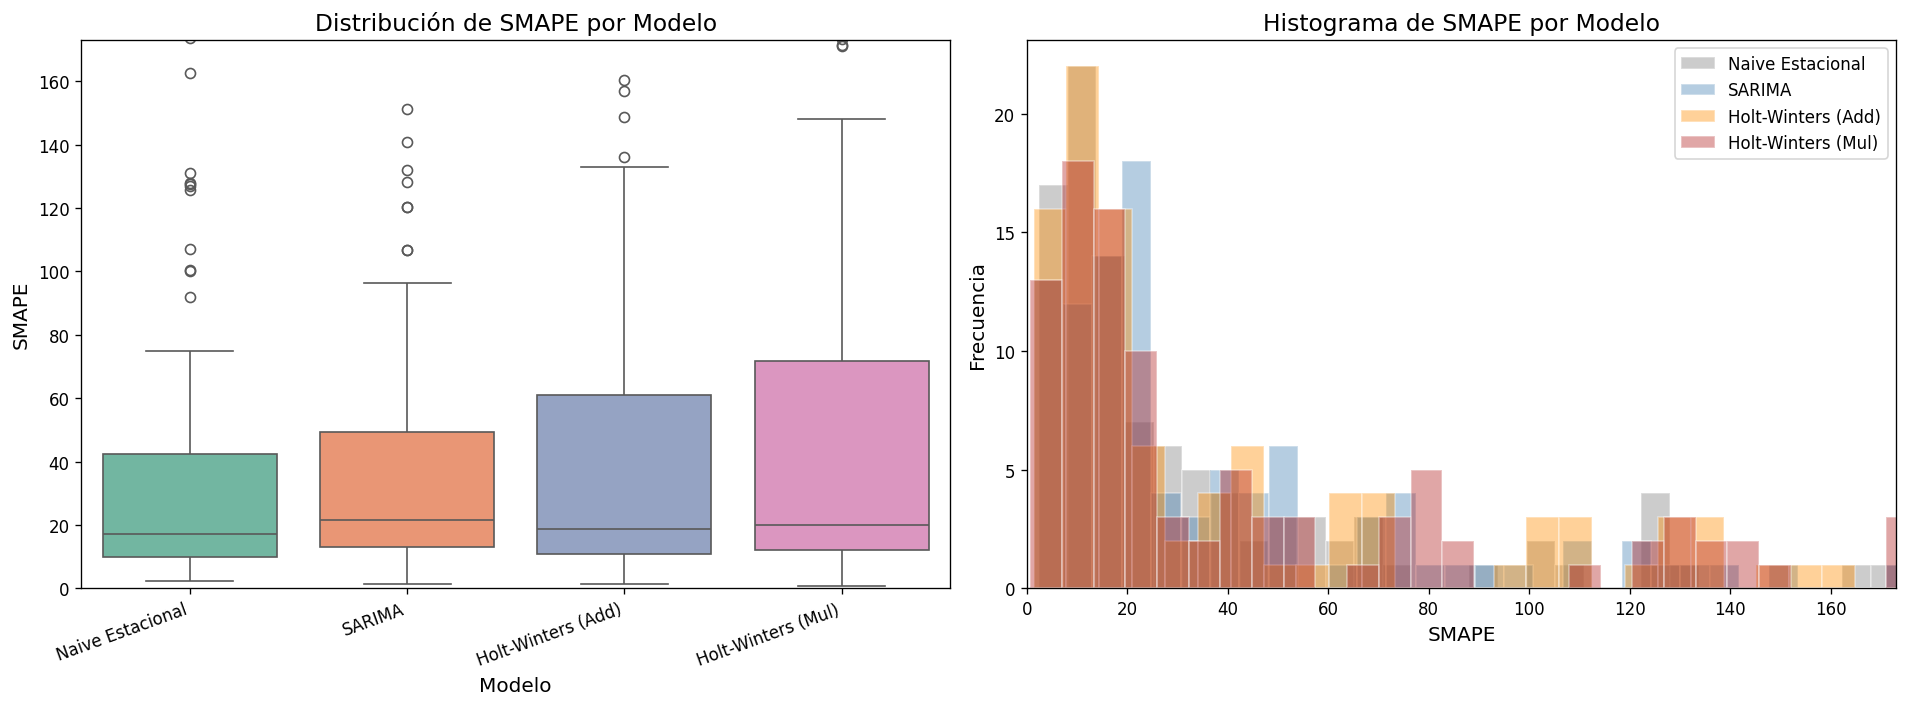

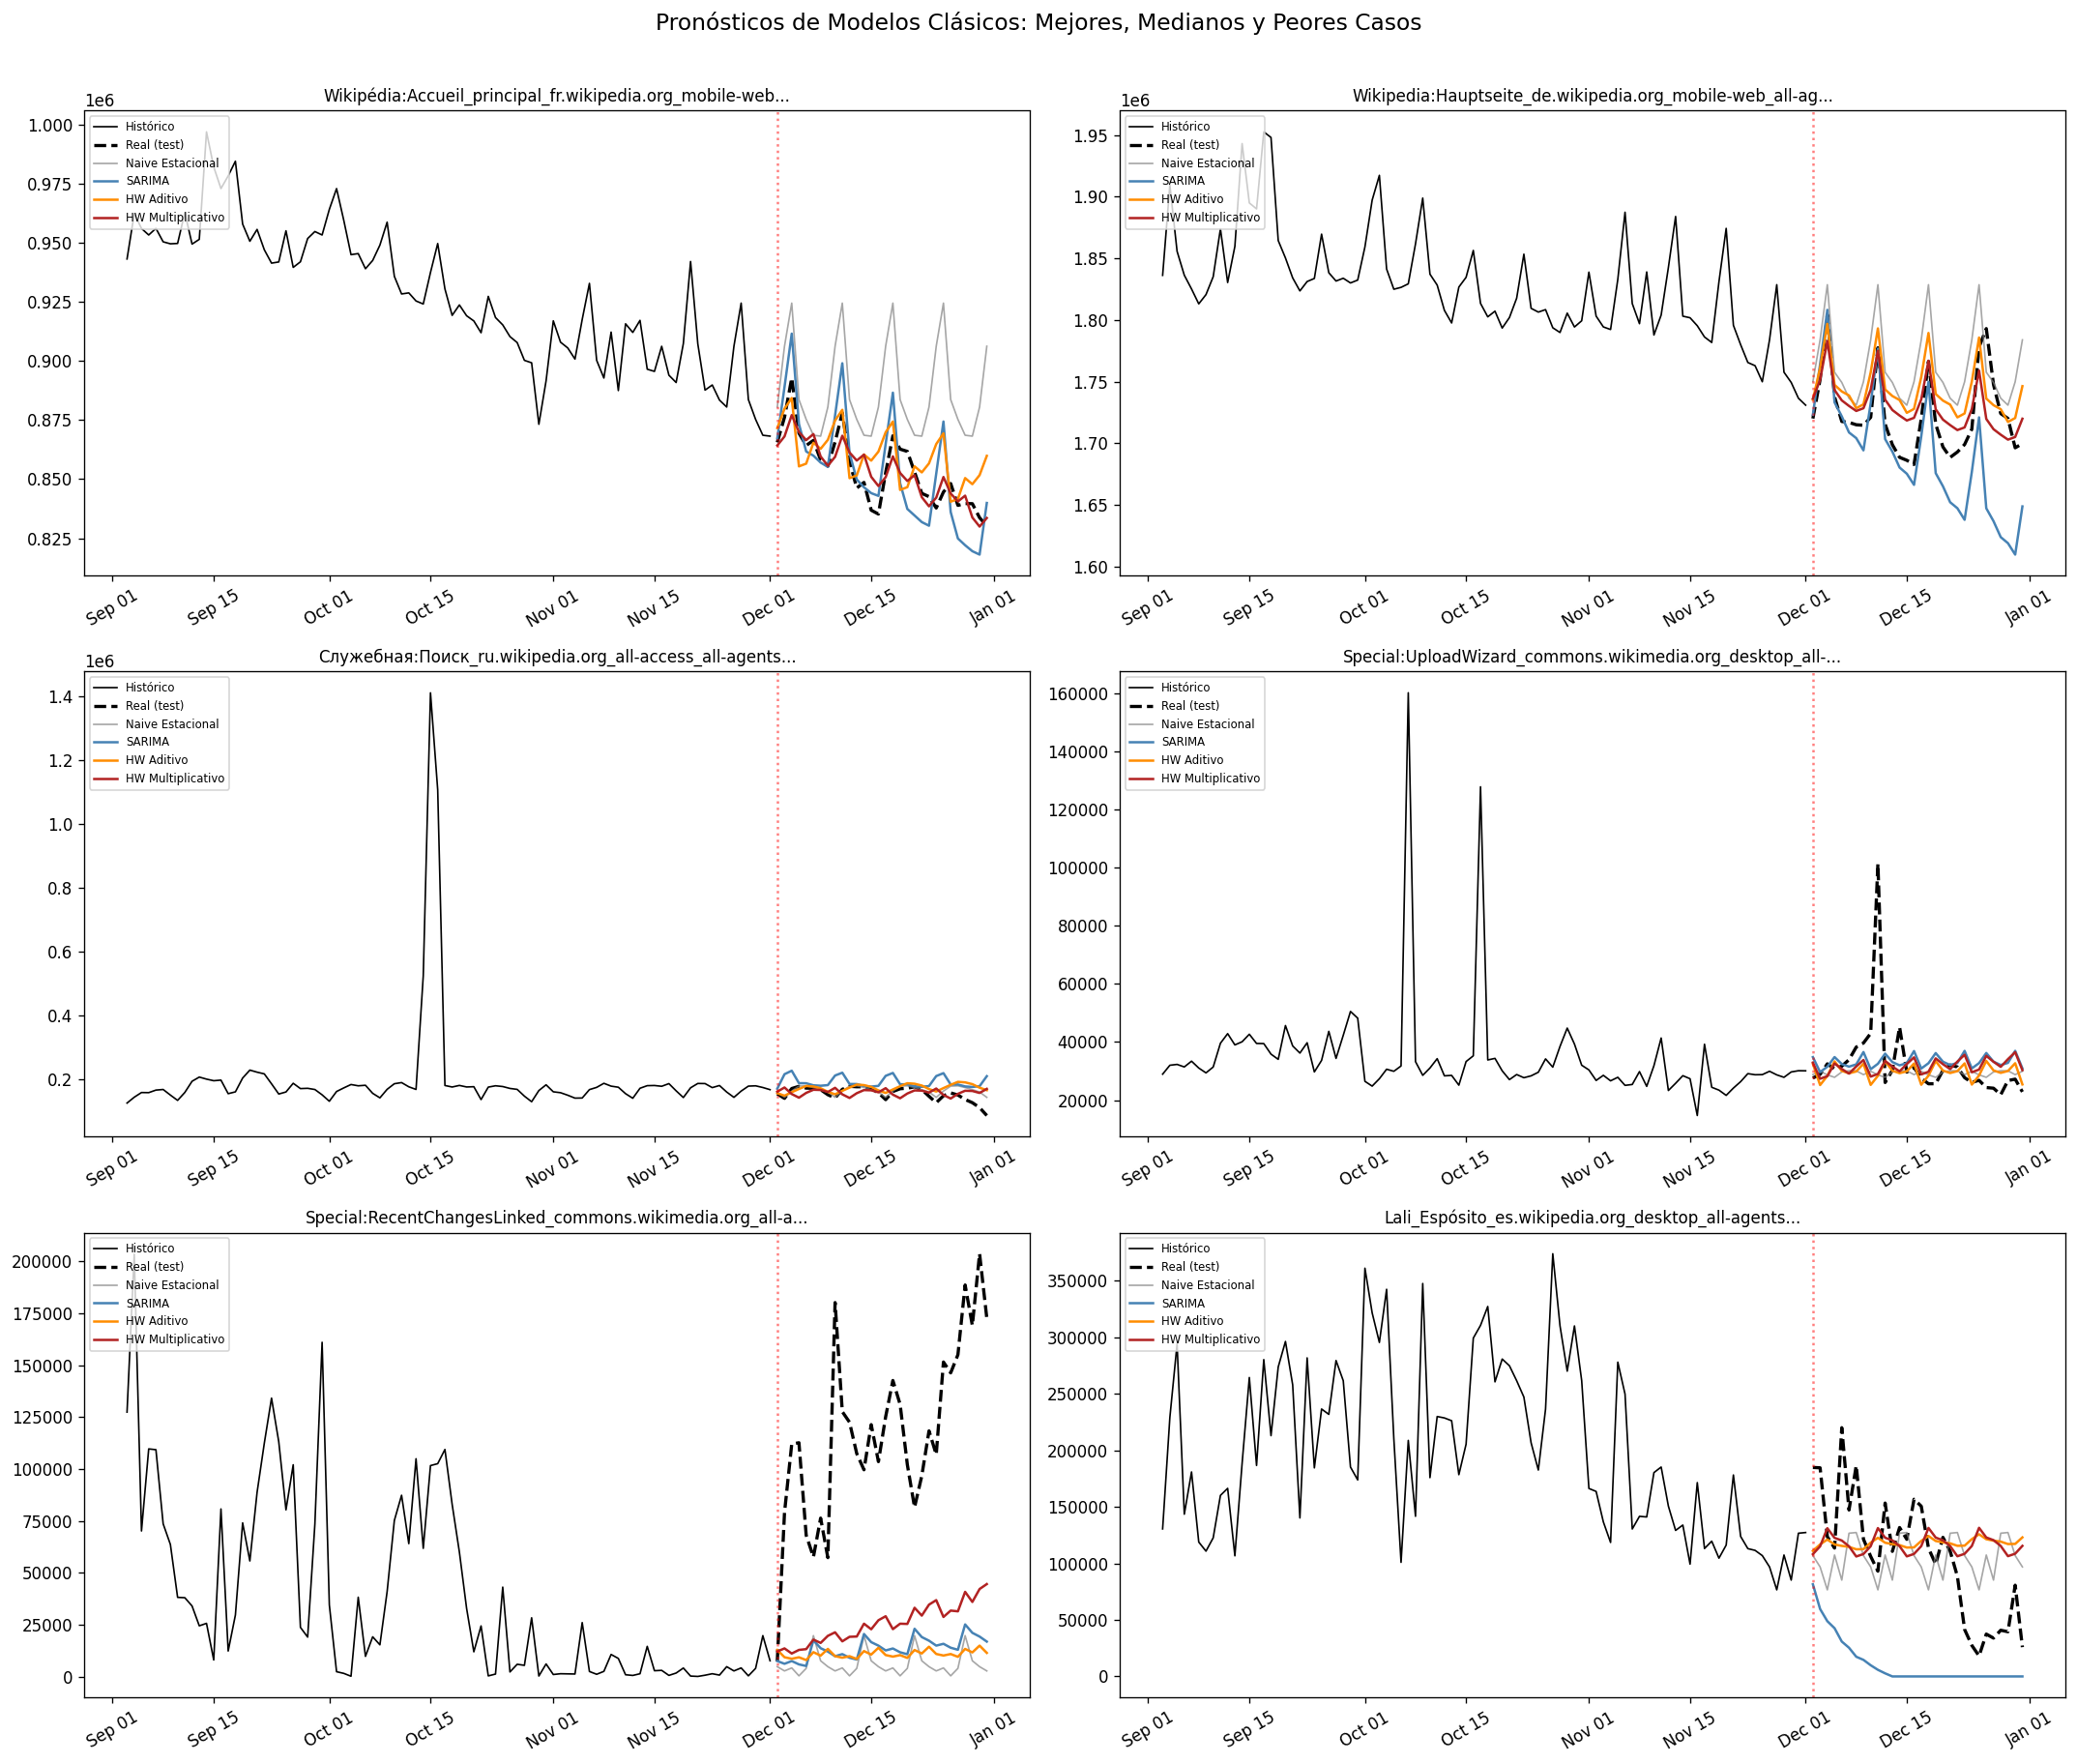

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: boxplots
smape_data = results_df[smape_cols].copy()
smape_data.columns = model_names
smape_melted = smape_data.melt(var_name='Modelo', value_name='SMAPE')

sns.boxplot(data=smape_melted, x='Modelo', y='SMAPE', palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de SMAPE por Modelo')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].set_ylim(0, min(200, smape_melted['SMAPE'].quantile(0.95) * 1.3))

# Panel derecho: histogramas superpuestos
for col, name, color in zip(smape_cols, model_names,
                            ['gray', 'steelblue', 'darkorange', 'firebrick']):
    vals = results_df[col].dropna()
    axes[1].hist(vals, bins=30, alpha=0.4, label=name, color=color, edgecolor='white')

axes[1].set_title('Histograma de SMAPE por Modelo')
axes[1].set_xlabel('SMAPE')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].set_xlim(0, min(200, smape_melted['SMAPE'].quantile(0.95) * 1.3))

plt.tight_layout()
plt.savefig('fig10_smape_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
def plot_forecast(result, test_dates, train_dates, ax):
    """Grafica los pronósticos de todos los modelos para una serie."""
    # Últimos 90 días de entrenamiento + horizonte de prueba
    n_context = 90

    y_true = result['y_true']
    page = result['page']

    # Contexto de entrenamiento
    series = prepare_series(df.loc[result['page_idx']], date_cols, dates)
    train_context = series.iloc[train_end_idx - n_context:train_end_idx]

    ax.plot(train_context.index, train_context.values,
            color='black', linewidth=1.0, label='Histórico')
    ax.plot(test_dates, y_true,
            color='black', linewidth=2.0, linestyle='--', label='Real (test)')
    ax.plot(test_dates, result['naive_pred'],
            color='gray', linewidth=1.0, alpha=0.7, label='Naive Estacional')

    if result['sarima_pred'] is not None:
        ax.plot(test_dates, result['sarima_pred'],
                color='steelblue', linewidth=1.5, label='SARIMA')
    if result['hw_add_pred'] is not None:
        ax.plot(test_dates, result['hw_add_pred'],
                color='darkorange', linewidth=1.5, label='HW Aditivo')
    if result['hw_mul_pred'] is not None:
        ax.plot(test_dates, result['hw_mul_pred'],
                color='firebrick', linewidth=1.5, label='HW Multiplicativo')

    ax.axvline(x=test_dates[0], color='red', linestyle=':', alpha=0.5)
    ax.set_title(f"{page[:55]}...", fontsize=10)
    ax.legend(fontsize=7, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)


sarima_valid = results_df.dropna(subset=['smape_sarima']).sort_values('smape_sarima')
n_valid = len(sarima_valid)

example_indices = []
example_indices.extend(sarima_valid.index[:2].tolist())                        # 2 mejores
example_indices.extend(sarima_valid.index[n_valid//2 - 1: n_valid//2 + 1].tolist())  # 2 medianas
example_indices.extend(sarima_valid.index[-2:].tolist())                       # 2 peores

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes_flat = axes.flatten()

for ax, ex_idx in zip(axes_flat, example_indices):
    result = results_list[ex_idx]
    plot_forecast(result, test_dates, train_dates, ax)

plt.suptitle('Pronósticos de Modelos Clásicos: Mejores, Medianos y Peores Casos',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig11_pronosticos_individuales.png', dpi=150, bbox_inches='tight')
plt.show()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Dataset: 145,063 páginas x 550 días
Train: 2015-07-01 -> 2016-12-01 (520 días)
Test:  2016-12-02 -> 2016-12-31 (30 días)
Metadatos de las páginas
Idiomas:  9 -> {'en': 24108, 'ja': 20431, 'de': 18547, 'fr': 17802, 'zh': 17229}
Accesos:  3 -> {'all-access': 74315, 'mobile-web': 35939, 'desktop': 34809}
Agentes:  2 -> {'all-agents': 110150, 'spider': 34913}
Segmentación por tiers de tráfico:
  ALTO  (top 1%, mediana >= 7001): 1,300 páginas
  MEDIO (p25-p99, mediana >= 15):  98,442 páginas
  BAJO  (bottom 25%):                    45,321 páginas
Ajustando Prophet sobre 100


19:20:45 - cmdstanpy - INFO - Chain [1] start processing
19:20:45 - cmdstanpy - INFO - Chain [1] done processing
19:20:45 - cmdstanpy - INFO - Chain [1] start processing
19:20:45 - cmdstanpy - INFO - Chain [1] done processing
19:20:45 - cmdstanpy - INFO - Chain [1] start processing
19:20:45 - cmdstanpy - INFO - Chain [1] done processing
19:20:45 - cmdstanpy - INFO - Chain [1] start processing
19:20:45 - cmdstanpy - INFO - Chain [1] done processing
19:20:46 - cmdstanpy - INFO - Chain [1] start processing
19:20:46 - cmdstanpy - INFO - Chain [1] done processing
19:20:46 - cmdstanpy - INFO - Chain [1] start processing
19:20:46 - cmdstanpy - INFO - Chain [1] done processing
19:20:46 - cmdstanpy - INFO - Chain [1] start processing
19:20:46 - cmdstanpy - INFO - Chain [1] done processing
19:20:46 - cmdstanpy - INFO - Chain [1] start processing
19:20:46 - cmdstanpy - INFO - Chain [1] done processing
19:20:46 - cmdstanpy - INFO - Chain [1] start processing
19:20:46 - cmdstanpy - INFO - Chain [1]

  20/100 series procesadas (5s)


19:20:49 - cmdstanpy - INFO - Chain [1] start processing
19:20:49 - cmdstanpy - INFO - Chain [1] done processing
19:20:49 - cmdstanpy - INFO - Chain [1] start processing
19:20:49 - cmdstanpy - INFO - Chain [1] done processing
19:20:49 - cmdstanpy - INFO - Chain [1] start processing
19:20:49 - cmdstanpy - INFO - Chain [1] done processing
19:20:49 - cmdstanpy - INFO - Chain [1] start processing
19:20:49 - cmdstanpy - INFO - Chain [1] done processing
19:20:50 - cmdstanpy - INFO - Chain [1] start processing
19:20:50 - cmdstanpy - INFO - Chain [1] done processing
19:20:50 - cmdstanpy - INFO - Chain [1] start processing
19:20:50 - cmdstanpy - INFO - Chain [1] done processing
19:20:50 - cmdstanpy - INFO - Chain [1] start processing
19:20:50 - cmdstanpy - INFO - Chain [1] done processing
19:20:50 - cmdstanpy - INFO - Chain [1] start processing
19:20:50 - cmdstanpy - INFO - Chain [1] done processing
19:20:50 - cmdstanpy - INFO - Chain [1] start processing
19:20:50 - cmdstanpy - INFO - Chain [1]

  40/100 series procesadas (8s)


...

  60/100 series procesadas (12s)


19:20:56 - cmdstanpy - INFO - Chain [1] done processing
19:20:56 - cmdstanpy - INFO - Chain [1] start processing
19:20:56 - cmdstanpy - INFO - Chain [1] done processing
19:20:56 - cmdstanpy - INFO - Chain [1] start processing
19:20:56 - cmdstanpy - INFO - Chain [1] done processing
19:20:56 - cmdstanpy - INFO - Chain [1] start processing
19:20:56 - cmdstanpy - INFO - Chain [1] done processing
19:20:56 - cmdstanpy - INFO - Chain [1] start processing
19:20:56 - cmdstanpy - INFO - Chain [1] done processing
19:20:56 - cmdstanpy - INFO - Chain [1] start processing
19:20:56 - cmdstanpy - INFO - Chain [1] done processing
19:20:56 - cmdstanpy - INFO - Chain [1] start processing
19:20:57 - cmdstanpy - INFO - Chain [1] done processing
19:20:57 - cmdstanpy - INFO - Chain [1] start processing
19:20:57 - cmdstanpy - INFO - Chain [1] done processing
19:20:57 - cmdstanpy - INFO - Chain [1] start processing
19:20:57 - cmdstanpy - INFO - Chain [1] done processing
19:20:57 - cmdstanpy - INFO - Chain [1] 

  80/100 series procesadas (15s)


19:20:59 - cmdstanpy - INFO - Chain [1] done processing
19:20:59 - cmdstanpy - INFO - Chain [1] start processing
19:20:59 - cmdstanpy - INFO - Chain [1] done processing
19:20:59 - cmdstanpy - INFO - Chain [1] start processing
19:20:59 - cmdstanpy - INFO - Chain [1] done processing
19:20:59 - cmdstanpy - INFO - Chain [1] start processing
19:20:59 - cmdstanpy - INFO - Chain [1] done processing
19:20:59 - cmdstanpy - INFO - Chain [1] start processing
19:21:00 - cmdstanpy - INFO - Chain [1] done processing
19:21:00 - cmdstanpy - INFO - Chain [1] start processing
19:21:00 - cmdstanpy - INFO - Chain [1] done processing
19:21:00 - cmdstanpy - INFO - Chain [1] start processing
19:21:00 - cmdstanpy - INFO - Chain [1] done processing
19:21:00 - cmdstanpy - INFO - Chain [1] start processing
19:21:00 - cmdstanpy - INFO - Chain [1] done processing
19:21:00 - cmdstanpy - INFO - Chain [1] start processing
19:21:00 - cmdstanpy - INFO - Chain [1] done processing
19:21:00 - cmdstanpy - INFO - Chain [1] 

  100/100 series procesadas (18s)
Prophet completado en 0.3 minutos

Resultados Prophet:
  SMAPE Medio:   53.92
  SMAPE Mediana: 22.75
  Series exitosas: 100/100
Construyendo features para LightGBM...
  Series tier alto: 1,300
  Series tier medio (muestra): 5,000
  Total series: 6,300
  1000/6300 series procesadas (126s)
  2000/6300 series procesadas (250s)
  3000/6300 series procesadas (383s)
  4000/6300 series procesadas (505s)
  5000/6300 series procesadas (629s)
  6000/6300 series procesadas (750s)

Feature engineering completado en 13.4 minutos
Dataframe de features: 3,244,500 filas x 20 columnas
Memoria: 0.59 GB
Train: 3,055,500 filas
Test:  189,000 filas
Entrenando LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 239.163
[200]	valid_0's l1: 235.164
[300]	valid_0's l1: 233.14
[400]	valid_0's l1: 230.905
[500]	valid_0's l1: 229.489
[600]	valid_0's l1: 228.492
[700]	valid_0's l1: 227.554
[800]	valid_0's l1: 226.692
[900]	valid_0's l1: 226

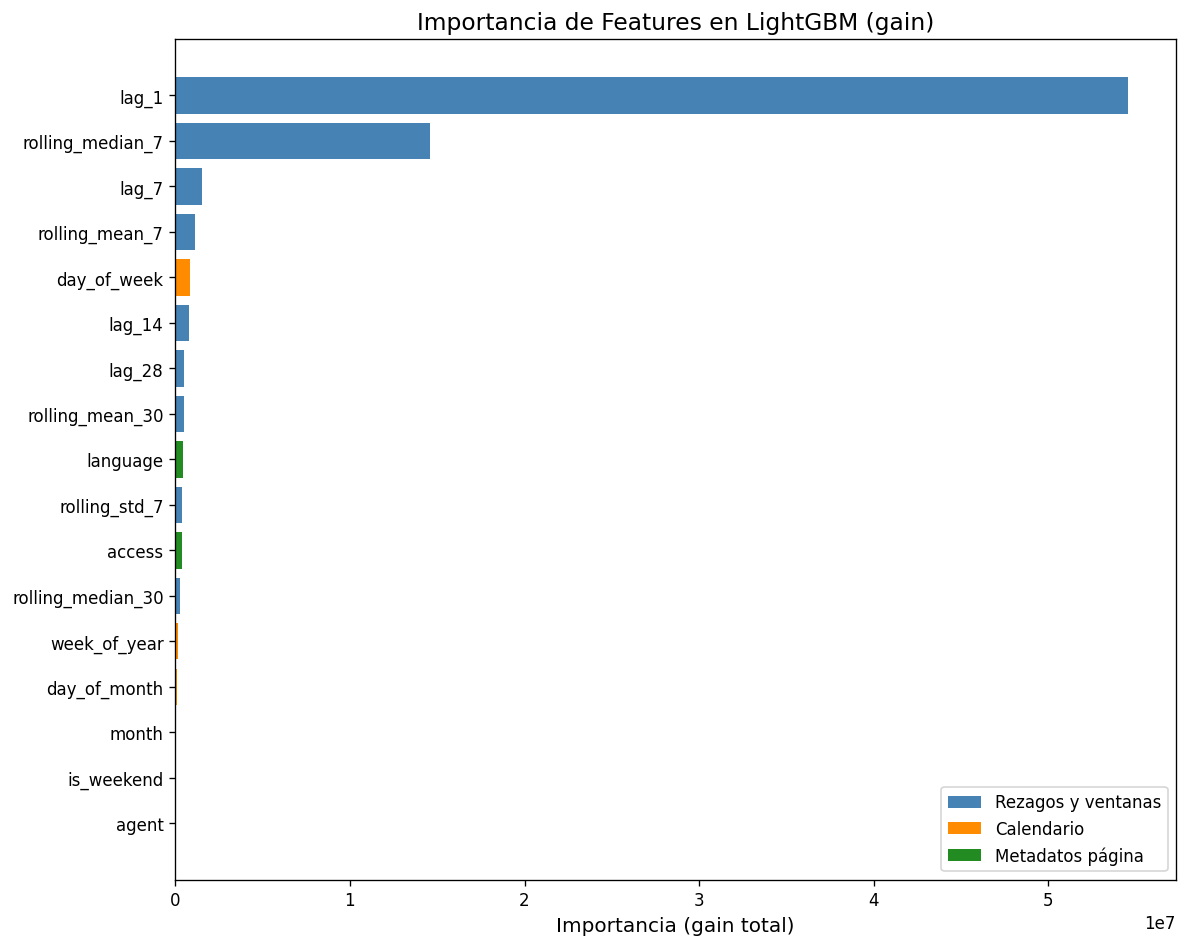


Top 10 features:
  lag_1                      54,580,504
  rolling_median_7           14,574,647
  lag_7                      1,524,162
  rolling_mean_7             1,146,617
  day_of_week                841,468
  lag_14                     777,550
  lag_28                     485,009
  rolling_mean_30            475,181
  language                   430,884
  rolling_std_7              398,988
Evaluando Naive Estacional sobre muestra
  Naive Estacional tier bajo (n=1947):
    SMAPE Medio:   66.92
    SMAPE Mediana: 59.49
Prophet                   53.92          22.75           Parcial
LightGBM Global           25.18          16.03           Si


SMAPE por Tier de Tráfico (estrategia óptima por segmento):

Tier           Modelo Óptimo         SMAPE Medio   N Series

Alto (top 1%)  Prophet/LightGBM      53.92          100
Medio (p25-99) LightGBM Global       20.09          6,300
Bajo (<p25)    Naive Estacional       66.92          1,947




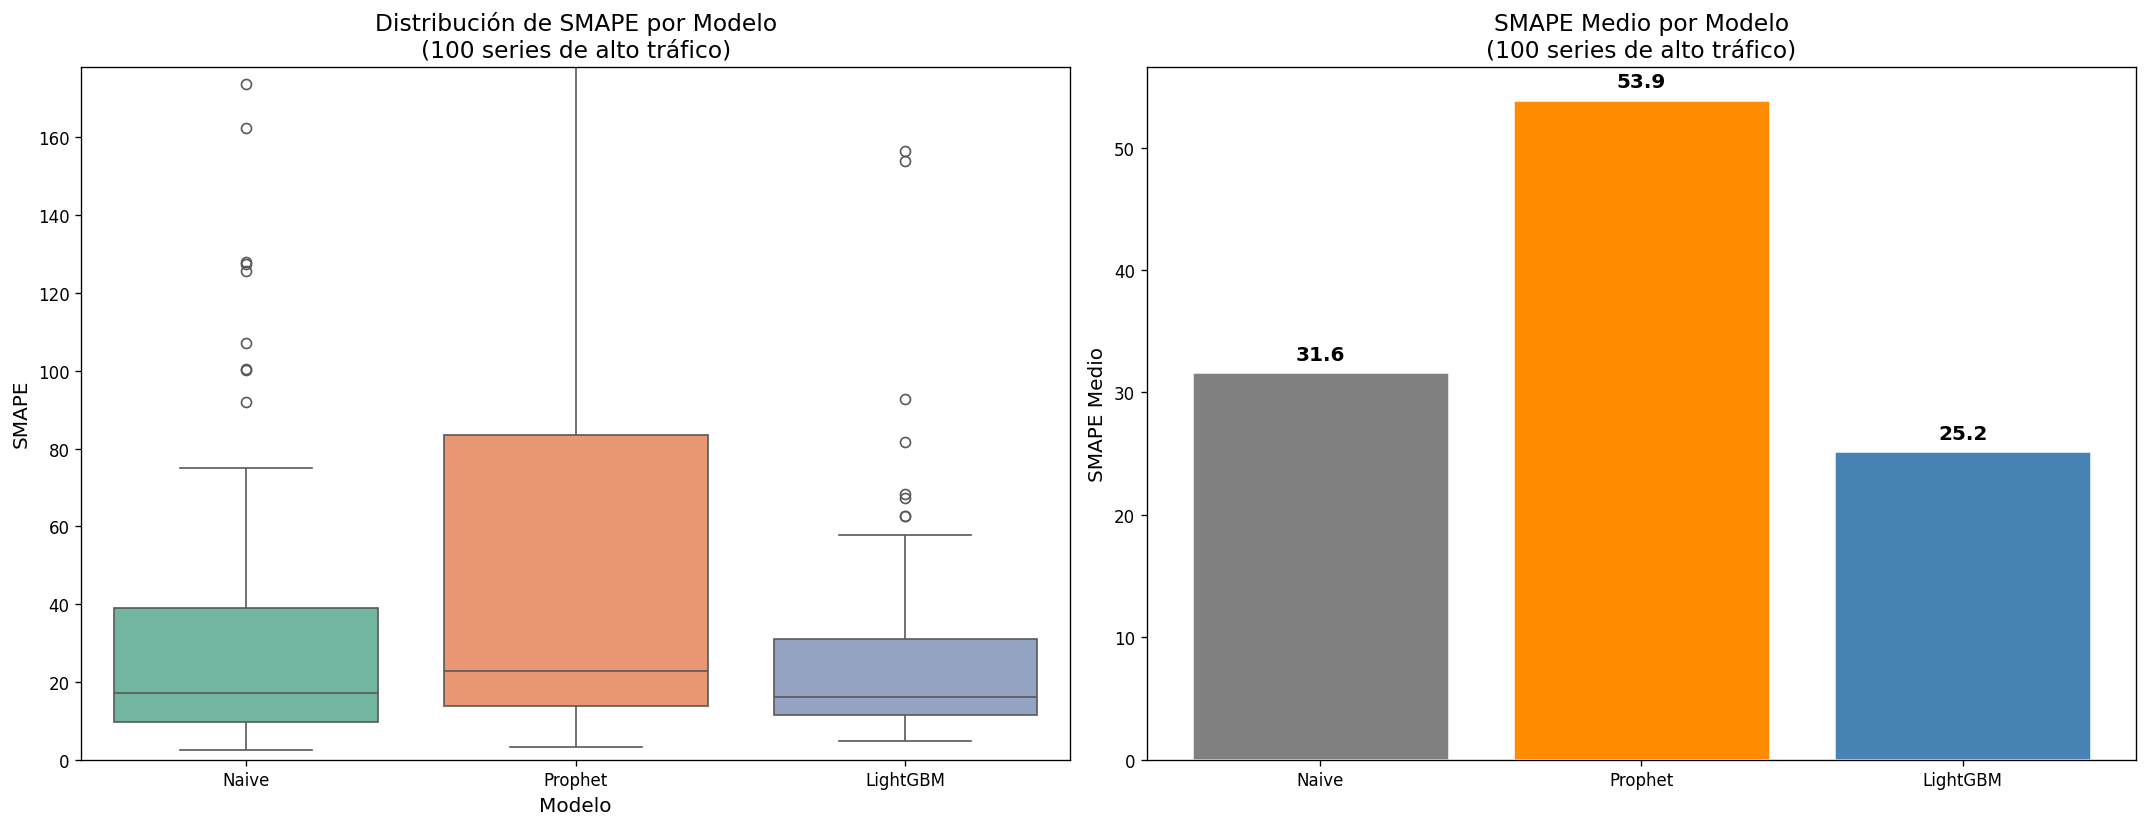

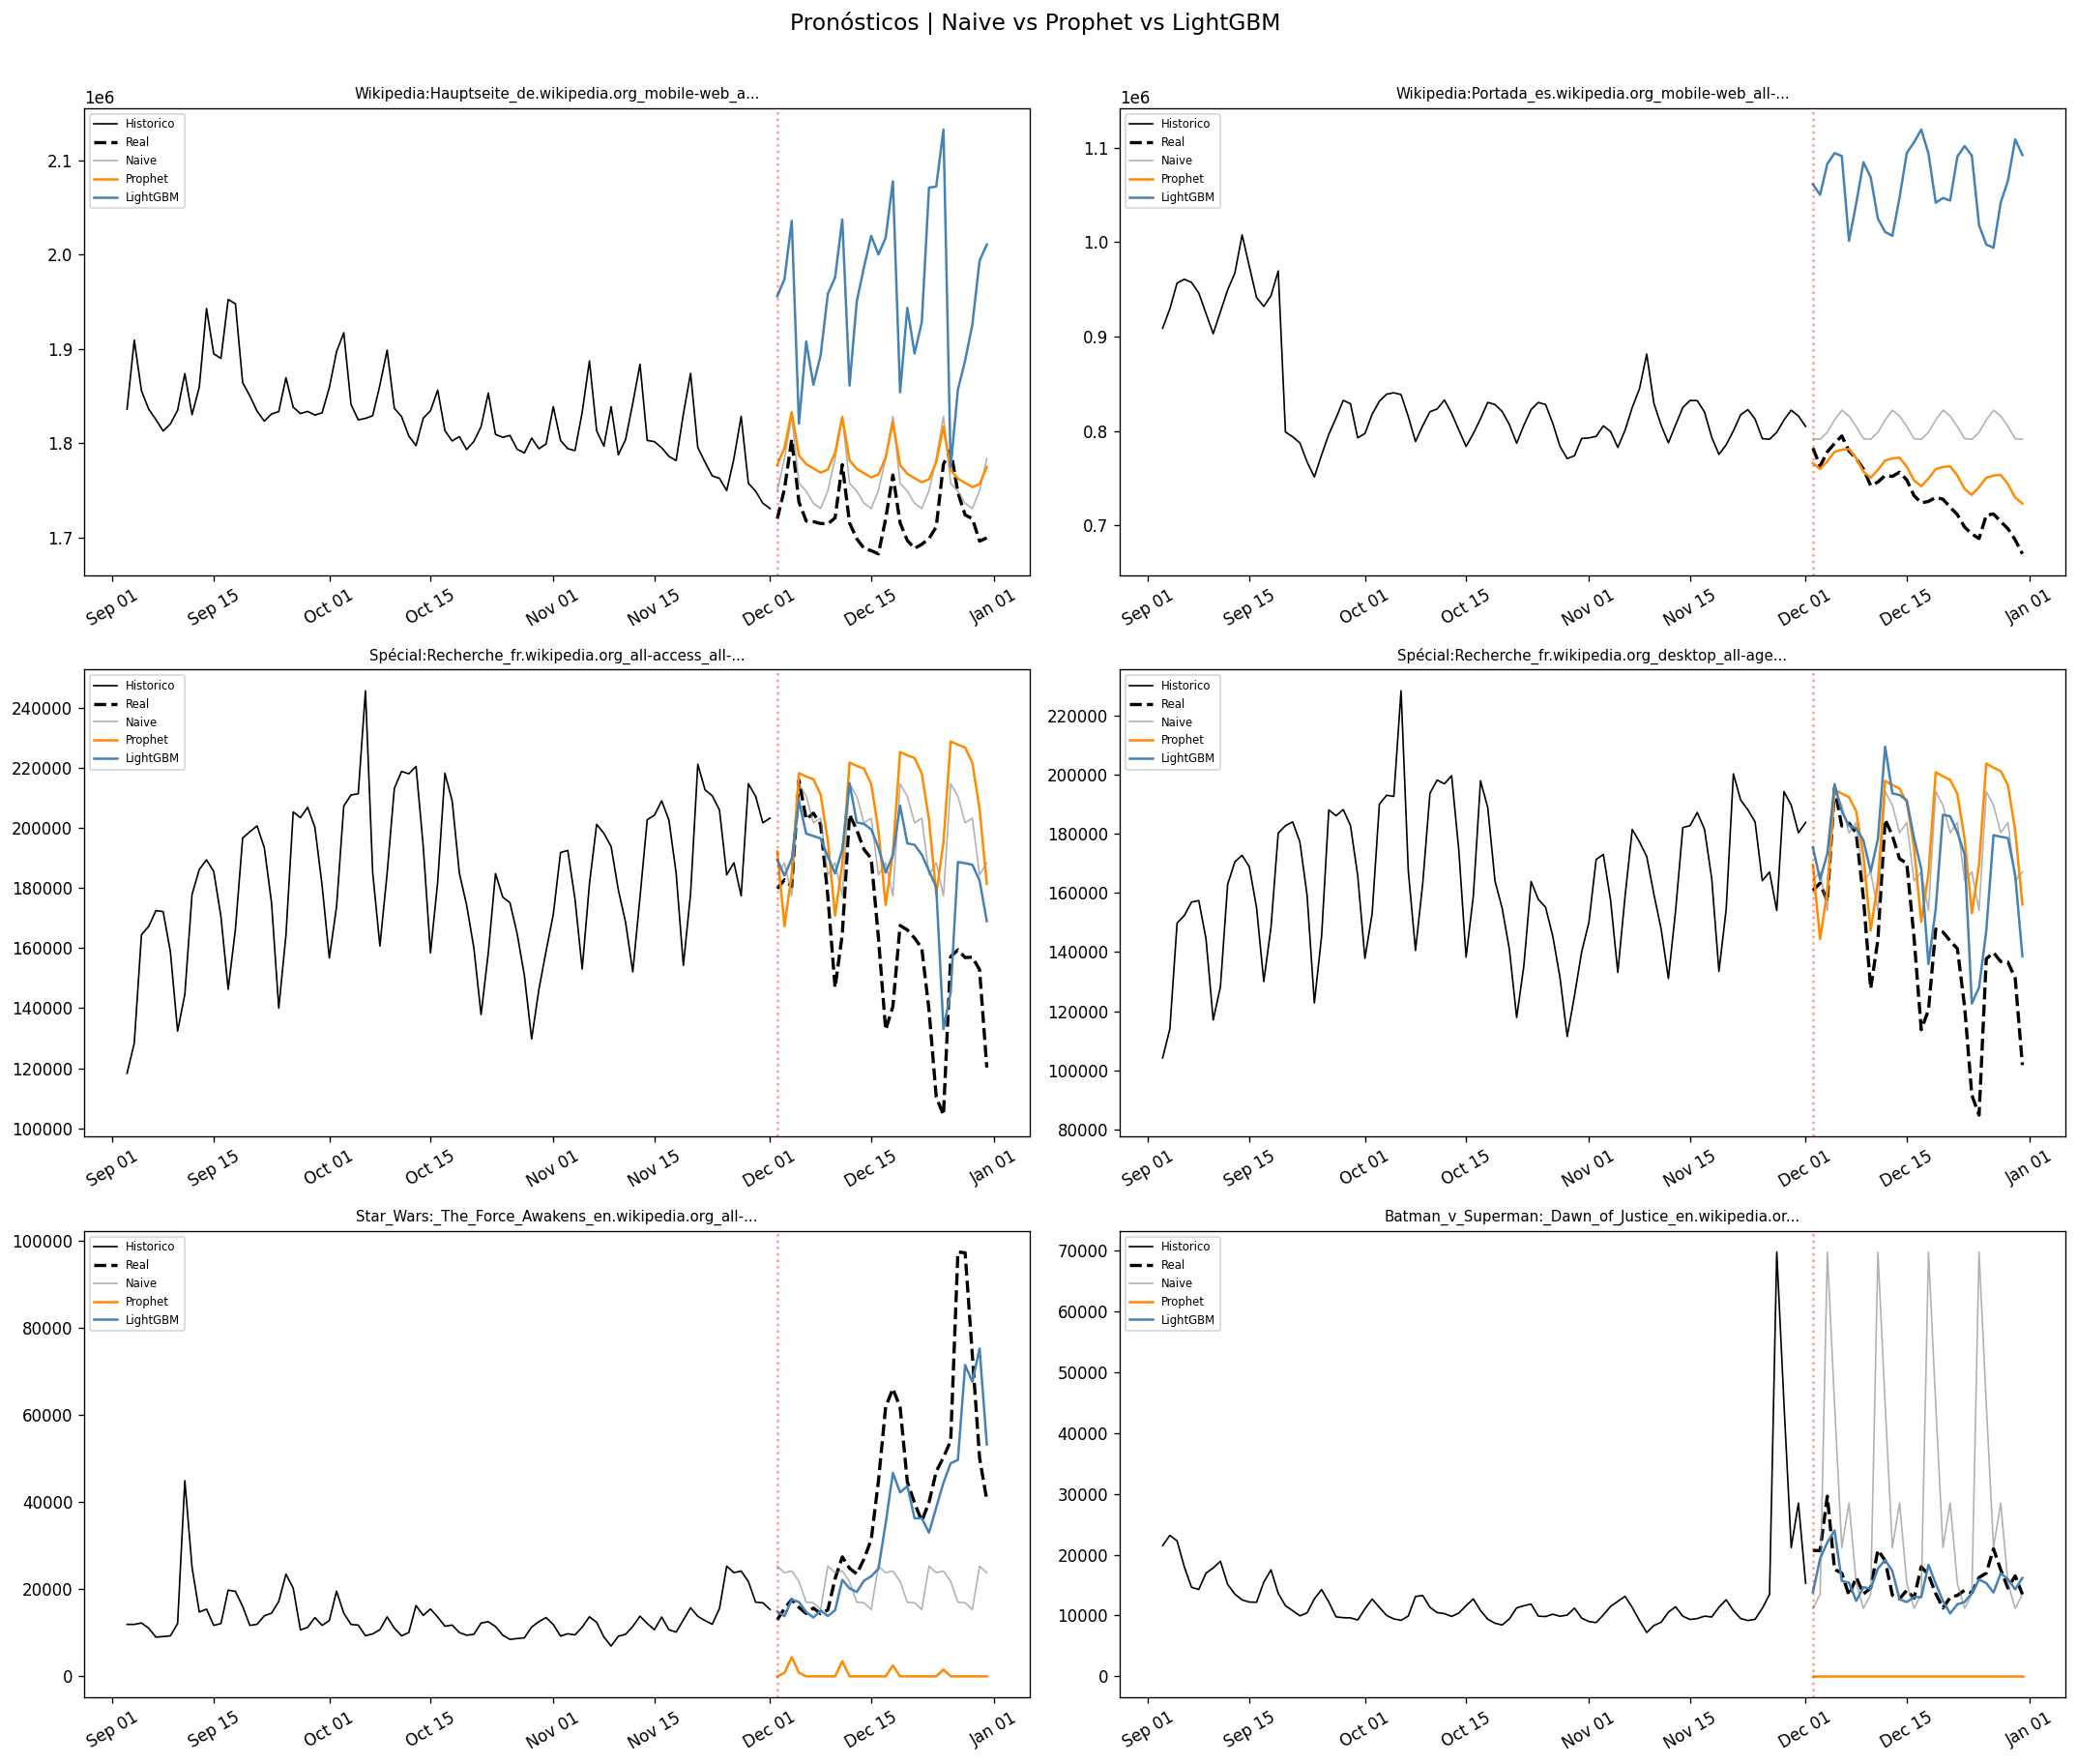

19:37:31 - cmdstanpy - INFO - Chain [1] start processing
19:37:31 - cmdstanpy - INFO - Chain [1] done processing


LightGBM serie agregada SMAPE: 3.56
Prophet sobre serie agregada
  Prophet SMAPE: 4.67
  Naive   SMAPE: 5.79


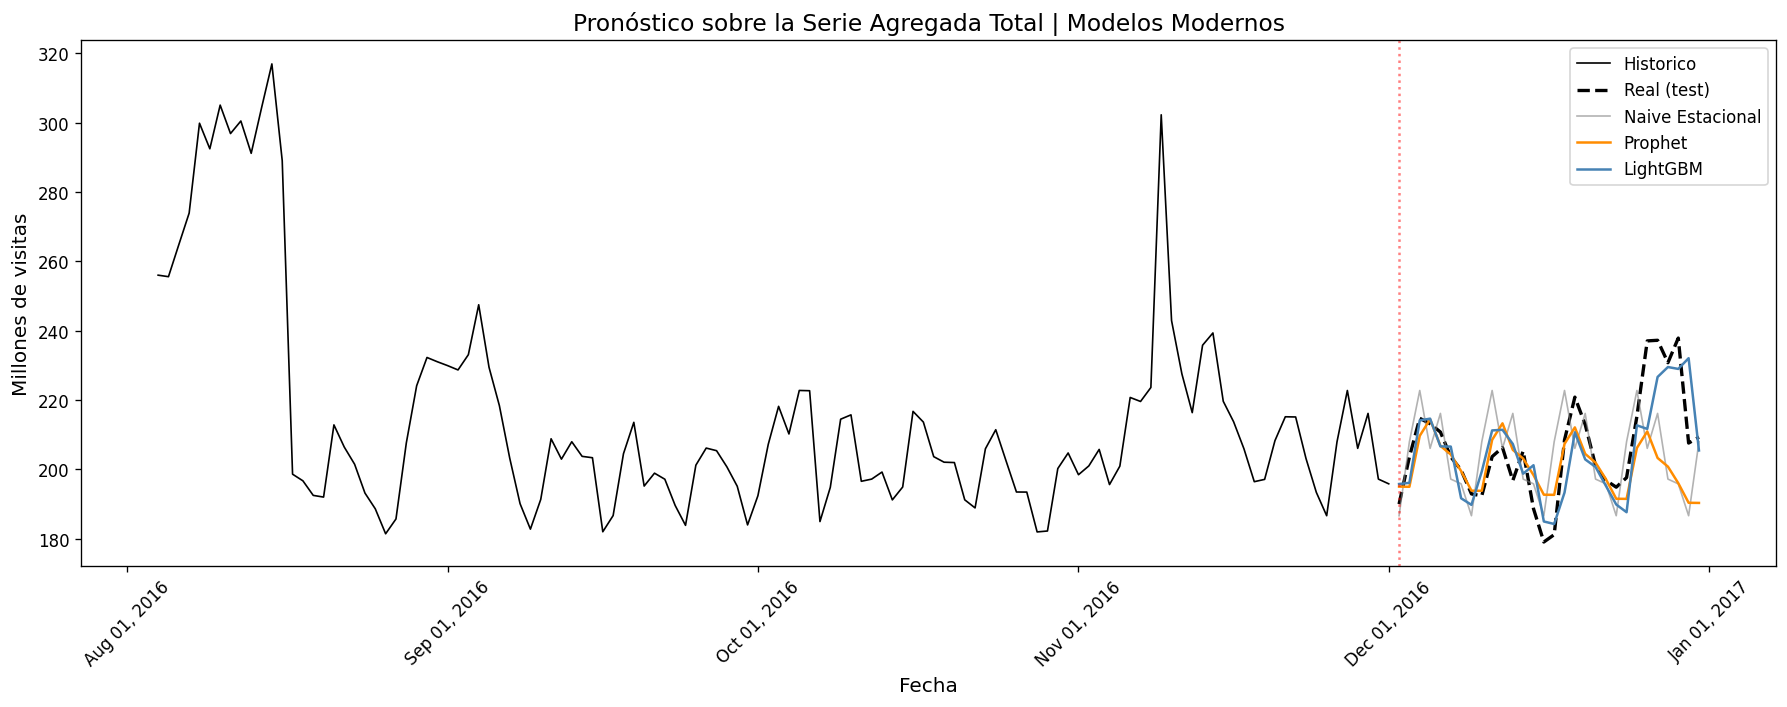

In [2]:
%pip install prophet
%pip install lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet
import lightgbm as lgb
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120
})

path = "/home/Beristain/Documentos/IPN/web-traffic-time-series-forecasting"

df = pd.read_csv(path + "/train_1.csv")
date_cols = df.columns[1:]
dates = pd.to_datetime(date_cols)

HORIZON = 30
train_end_idx = len(date_cols) - HORIZON
train_dates = dates[:train_end_idx]
test_dates = dates[train_end_idx:]

print(f"Dataset: {df.shape[0]:,} páginas x {len(date_cols)} días")
print(f"Train: {train_dates[0].date()} -> {train_dates[-1].date()} ({len(train_dates)} días)")
print(f"Test:  {test_dates[0].date()} -> {test_dates[-1].date()} ({len(test_dates)} días)")

def smape(y_true, y_pred):
    """SMAPE: Symmetric Mean Absolute Percentage Error. Rango [0, 200]."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom > 0
    return 200.0 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])


def parse_page_name(page_name):
    """Extrae idioma, tipo de acceso y tipo de agente del nombre de la página."""
    parts = page_name.split("_")
    agent = parts[-1]
    access = parts[-2]
    site_part = [p for p in parts if 'wikipedia.org' in p or 'wikimedia.org' in p]
    if site_part:
        lang = site_part[0].split('.')[0]
    else:
        lang = 'unknown'
    return lang, access, agent


def prepare_series(row, date_cols, dates):
    """Prepara una serie individual con forward fill."""
    series = pd.Series(row[date_cols].values.astype(float), index=dates)
    series = series.ffill().bfill().fillna(0)
    series.name = row['Page'][:60]
    return series


def naive_seasonal_forecast(train_series, horizon, season=7):
    """Pronóstico naive estacional."""
    last_season = train_series.values[-season:]
    n_repeats = int(np.ceil(horizon / season))
    return np.tile(last_season, n_repeats)[:horizon]

print("Metadatos de las páginas")
meta_list = []
for page in df['Page']:
    lang, access, agent = parse_page_name(page)
    meta_list.append({'language': lang, 'access': access, 'agent': agent})

meta_df = pd.DataFrame(meta_list)
print(f"Idiomas:  {meta_df['language'].nunique()} -> {meta_df['language'].value_counts().head().to_dict()}")
print(f"Accesos:  {meta_df['access'].nunique()} -> {meta_df['access'].value_counts().to_dict()}")
print(f"Agentes:  {meta_df['agent'].nunique()} -> {meta_df['agent'].value_counts().to_dict()}")

# Calcular métricas por página
median_traffic = df[date_cols].median(axis=1)
null_pct = df[date_cols].isnull().mean(axis=1)

# Definir tiers
TIER_HIGH_THRESHOLD = median_traffic.quantile(0.99)    
TIER_MID_THRESHOLD = median_traffic.quantile(0.25)    

tier_high = (median_traffic >= TIER_HIGH_THRESHOLD) & (null_pct < 0.05)
tier_mid = (median_traffic >= TIER_MID_THRESHOLD) & (~tier_high) & (null_pct < 0.20)
tier_low = ~(tier_high | tier_mid)

print(f"Segmentación por tiers de tráfico:")
print(f"  ALTO  (top 1%, mediana >= {TIER_HIGH_THRESHOLD:.0f}): {tier_high.sum():,} páginas")
print(f"  MEDIO (p25-p99, mediana >= {TIER_MID_THRESHOLD:.0f}):  {tier_mid.sum():,} páginas")
print(f"  BAJO  (bottom 25%):                    {tier_low.sum():,} páginas")

# Seleccionar subconjuntos
idx_high = df.index[tier_high].tolist()
idx_mid = df.index[tier_mid].tolist()
idx_low = df.index[tier_low].tolist()

traffic_total = df[date_cols].sum(axis=1)
idx_prophet = traffic_total[tier_high].nlargest(100).index.tolist()

def fit_prophet(train_series, horizon):
    """
    Ajusta Prophet con estacionalidad semanal automática.
    Retorna predicciones y el modelo ajustado.
    """
    # Prophet requiere DataFrame con columnas 'ds' y 'y'
    prophet_df = pd.DataFrame({
        'ds': train_series.index,
        'y': train_series.values
    })

    model = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=False,  
        daily_seasonality=False,
        changepoint_prior_scale=0.05,  
        seasonality_prior_scale=10.0,
    )
    model.fit(prophet_df)

    # Crear dataframe futuro
    future = model.make_future_dataframe(periods=horizon)
    forecast = model.predict(future)

    # Extraer solo las predicciones del horizonte
    pred = forecast.tail(horizon)['yhat'].values
    pred = np.clip(pred, 0, None)  

    return pred, model


print(f"Ajustando Prophet sobre {len(idx_prophet)}")
prophet_results = []
start_time = time.time()

for i, idx in enumerate(idx_prophet):
    row = df.loc[idx]
    series = prepare_series(row, date_cols, dates)
    train = series.iloc[:train_end_idx]
    test = series.iloc[train_end_idx:]
    y_true = test.values

    try:
        prophet_pred, _ = fit_prophet(train, HORIZON)
        smape_prophet = smape(y_true, prophet_pred)
    except Exception as e:
        prophet_pred = None
        smape_prophet = np.nan

    # Naive para comparación
    naive_pred = naive_seasonal_forecast(train, HORIZON)
    smape_naive = smape(y_true, naive_pred)

    prophet_results.append({
        'page': series.name,
        'page_idx': idx,
        'smape_prophet': smape_prophet,
        'smape_naive': smape_naive,
        'y_true': y_true,
        'prophet_pred': prophet_pred,
        'naive_pred': naive_pred,
        'mean_traffic': train.mean()
    })

    if (i + 1) % 20 == 0:
        elapsed = time.time() - start_time
        print(f"  {i+1}/{len(idx_prophet)} series procesadas ({elapsed:.0f}s)")

elapsed = time.time() - start_time
print(f"Prophet completado en {elapsed/60:.1f} minutos")

prophet_df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_true', 'prophet_pred', 'naive_pred']}
    for r in prophet_results
])

print(f"\nResultados Prophet:")
print(f"  SMAPE Medio:   {prophet_df_results['smape_prophet'].mean():.2f}")
print(f"  SMAPE Mediana: {prophet_df_results['smape_prophet'].median():.2f}")
print(f"  Series exitosas: {prophet_df_results['smape_prophet'].notna().sum()}/{len(prophet_df_results)}")

def create_features_for_series(series_values, series_idx, lang, access, agent,
                                dates, train_end_idx):
    """
    Construye el dataframe de features para una serie individual.
    Retorna filas de entrenamiento y de test.
    """
    n = len(series_values)
    rows = []

    for t in range(35, n):  
        date = dates[t]
        y = series_values[t]

        if np.isnan(y):
            continue

        row = {
            'y': y,
            'series_idx': series_idx,
            # --- Rezagos ---
            'lag_1': series_values[t - 1] if t >= 1 else np.nan,
            'lag_7': series_values[t - 7] if t >= 7 else np.nan,
            'lag_14': series_values[t - 14] if t >= 14 else np.nan,
            'lag_28': series_values[t - 28] if t >= 28 else np.nan,
            # --- Estadísticas de ventana deslizante ---
            'rolling_mean_7': np.nanmean(series_values[max(0, t-7):t]),
            'rolling_std_7': np.nanstd(series_values[max(0, t-7):t]),
            'rolling_median_7': np.nanmedian(series_values[max(0, t-7):t]),
            'rolling_mean_30': np.nanmean(series_values[max(0, t-30):t]),
            'rolling_median_30': np.nanmedian(series_values[max(0, t-30):t]),
            # --- Variables de calendario ---
            'day_of_week': date.dayofweek,
            'month': date.month,
            'is_weekend': 1 if date.dayofweek >= 5 else 0,
            'day_of_month': date.day,
            'week_of_year': date.isocalendar()[1],
            # --- Metadatos de la página ---
            'language': lang,
            'access': access,
            'agent': agent,
            # --- Flag de split ---
            'is_train': 1 if t < train_end_idx else 0,
        }
        rows.append(row)

    return rows

N_MID_SAMPLE = 5000 

np.random.seed(42)
idx_mid_sample = np.random.choice(idx_mid, size=min(N_MID_SAMPLE, len(idx_mid)),
                                   replace=False).tolist()
idx_lgbm = idx_high + idx_mid_sample

print(f"Construyendo features para LightGBM...")
print(f"  Series tier alto: {len(idx_high):,}")
print(f"  Series tier medio (muestra): {len(idx_mid_sample):,}")
print(f"  Total series: {len(idx_lgbm):,}")

all_rows = []
start_time = time.time()

for count, idx in enumerate(idx_lgbm):
    row = df.loc[idx]
    page = row['Page']
    lang, access, agent = parse_page_name(page)

    values = row[date_cols].values.astype(float)
    # Forward fill NaNs
    s = pd.Series(values)
    values = s.ffill().bfill().fillna(0).values

    rows = create_features_for_series(
        values, idx, lang, access, agent, dates, train_end_idx
    )
    all_rows.extend(rows)

    if (count + 1) % 1000 == 0:
        elapsed = time.time() - start_time
        print(f"  {count+1}/{len(idx_lgbm)} series procesadas ({elapsed:.0f}s)")

features_df = pd.DataFrame(all_rows)
elapsed = time.time() - start_time
print(f"\nFeature engineering completado en {elapsed/60:.1f} minutos")
print(f"Dataframe de features: {features_df.shape[0]:,} filas x {features_df.shape[1]} columnas")
print(f"Memoria: {features_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# LightGBM soporta variables categóricas de forma nativa
cat_cols = ['language', 'access', 'agent']
for col in cat_cols:
    features_df[col] = features_df[col].astype('category')

# Definir columnas de features
feature_cols = [
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_std_7', 'rolling_median_7',
    'rolling_mean_30', 'rolling_median_30',
    'day_of_week', 'month', 'is_weekend', 'day_of_month', 'week_of_year',
    'language', 'access', 'agent'
]

train_mask = features_df['is_train'] == 1
test_mask = features_df['is_train'] == 0

X_train = features_df.loc[train_mask, feature_cols]
y_train = features_df.loc[train_mask, 'y']
X_test = features_df.loc[test_mask, feature_cols]
y_test = features_df.loc[test_mask, 'y']
test_series_idx = features_df.loc[test_mask, 'series_idx'].values

print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")

# Crear datasets de LightGBM
train_data = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=cat_cols,
    free_raw_data=False
)

# Validación: usar una porción del final del entrenamiento
val_split = int(len(X_train) * 0.9)
X_val = X_train.iloc[val_split:]
y_val = y_train.iloc[val_split:]
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data,
                        categorical_feature=cat_cols)

# Hiperparámetros
params = {
    'objective': 'regression_l1',  
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 8,
    'min_child_samples': 50,
    'feature_fraction': 0.8,        
    'bagging_fraction': 0.8,       
    'bagging_freq': 5,
    'reg_alpha': 0.1,               
    'reg_lambda': 0.1,              
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42
}

print("Entrenando LightGBM...")
start_time = time.time()

model_lgbm = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

elapsed = time.time() - start_time
print(f"LightGBM entrenado en {elapsed:.0f} segundos")
print(f"Mejor iteración: {model_lgbm.best_iteration}")

# Predicciones sobre el test set
y_pred_lgbm = model_lgbm.predict(X_test)
y_pred_lgbm = np.clip(y_pred_lgbm, 0, None)  # No hay visitas negativas

# SMAPE global
smape_global = smape(y_test.values, y_pred_lgbm)
print(f"SMAPE Global LightGBM: {smape_global:.2f}")

# SMAPE por serie
unique_series = np.unique(test_series_idx)
lgbm_smape_per_series = {}

for s_idx in unique_series:
    mask = test_series_idx == s_idx
    if mask.sum() > 0:
        s_true = y_test.values[mask]
        s_pred = y_pred_lgbm[mask]
        lgbm_smape_per_series[s_idx] = smape(s_true, s_pred)

lgbm_smape_values = list(lgbm_smape_per_series.values())
print(f"SMAPE por serie (n={len(lgbm_smape_values)}):")
print(f"  Media:   {np.mean(lgbm_smape_values):.2f}")
print(f"  Mediana: {np.median(lgbm_smape_values):.2f}")
print(f"  Std:     {np.std(lgbm_smape_values):.2f}")

importance = model_lgbm.feature_importance(importance_type='gain')
feature_names = model_lgbm.feature_name()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(17, len(importance_df))
data = importance_df.head(top_n).iloc[::-1]

colors = ['steelblue' if 'lag' in f or 'rolling' in f
          else 'darkorange' if f in ['day_of_week', 'month', 'is_weekend',
                                      'day_of_month', 'week_of_year']
          else 'forestgreen'
          for f in data['feature']]

ax.barh(data['feature'], data['importance'], color=colors)
ax.set_title('Importancia de Features en LightGBM (gain)')
ax.set_xlabel('Importancia (gain total)')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Rezagos y ventanas'),
    Patch(facecolor='darkorange', label='Calendario'),
    Patch(facecolor='forestgreen', label='Metadatos página')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('fig15_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
for _, row in importance_df.head(10).iterrows():
    print(f"  {row['feature']:25s}  {row['importance']:,.0f}")

# Calcular SMAPE del tier bajo con Naive Estacional
print("Evaluando Naive Estacional sobre muestra")
n_low_sample = min(2000, len(idx_low))
idx_low_sample = np.random.choice(idx_low, size=n_low_sample, replace=False)

naive_smape_low = []
for idx in idx_low_sample:
    row = df.loc[idx]
    series = prepare_series(row, date_cols, dates)
    train = series.iloc[:train_end_idx]
    test_vals = series.iloc[train_end_idx:].values

    if np.all(test_vals == 0) and np.all(train.values[-7:] == 0):
        continue  # Excluir series completamente vacías

    naive_pred = naive_seasonal_forecast(train, HORIZON)
    naive_smape_low.append(smape(test_vals, naive_pred))

print(f"  Naive Estacional tier bajo (n={len(naive_smape_low)}):")
print(f"    SMAPE Medio:   {np.mean(naive_smape_low):.2f}")
print(f"    SMAPE Mediana: {np.median(naive_smape_low):.2f}")

prophet_mean = prophet_df_results['smape_prophet'].mean()
prophet_median = prophet_df_results['smape_prophet'].median()
print(f"Prophet                   {prophet_mean:.2f}          {prophet_median:.2f}           Parcial")

# SMAPE de LightGBM sobre las mismas 100 series de alto tráfico
lgbm_high_smapes = [lgbm_smape_per_series[idx] for idx in idx_prophet
                     if idx in lgbm_smape_per_series]
if lgbm_high_smapes:
    lgbm_high_mean = np.mean(lgbm_high_smapes)
    lgbm_high_median = np.median(lgbm_high_smapes)
    print(f"LightGBM Global           {lgbm_high_mean:.2f}          {lgbm_high_median:.2f}           Si")

print(f"""

SMAPE por Tier de Tráfico (estrategia óptima por segmento):

Tier           Modelo Óptimo         SMAPE Medio   N Series

Alto (top 1%)  Prophet/LightGBM      {prophet_mean:.2f}          {len(idx_prophet)}
Medio (p25-99) LightGBM Global       {np.mean(lgbm_smape_values):.2f}          {len(lgbm_smape_values):,}
Bajo (<p25)    Naive Estacional       {np.mean(naive_smape_low):.2f}          {len(naive_smape_low):,}

""")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel izquierdo: boxplots de SMAPE (100 series de alto tráfico) 
comparison_data = pd.DataFrame({
    'Naive': prophet_df_results['smape_naive'],
    'Prophet': prophet_df_results['smape_prophet'],
})

# LightGBM sobre las mismas 100 series
lgbm_for_100 = [lgbm_smape_per_series.get(idx, np.nan) for idx in idx_prophet]
comparison_data['LightGBM'] = lgbm_for_100


melted = comparison_data.melt(var_name='Modelo', value_name='SMAPE')
sns.boxplot(data=melted, x='Modelo', y='SMAPE', palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de SMAPE por Modelo\n(100 series de alto tráfico)')
axes[0].set_ylim(0, min(200, melted['SMAPE'].quantile(0.95) * 1.3))

# Panel derecho: SMAPE medio por modelo (barras)
model_names = ['Naive', 'Prophet', 'LightGBM']
smape_means = [
    prophet_df_results['smape_naive'].mean(),
    prophet_mean,
    np.mean(lgbm_high_smapes) if lgbm_high_smapes else np.nan,
]
colors = ['gray', 'darkorange', 'steelblue']

bars = axes[1].bar(model_names, smape_means, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('SMAPE Medio por Modelo\n(100 series de alto tráfico)')
axes[1].set_ylabel('SMAPE Medio')

for bar, val in zip(bars, smape_means):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_todos_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


def plot_all_forecasts(idx, prophet_results, lgbm_smape_per_series,
                       model_lgbm, features_df, df, date_cols, dates,
                       train_end_idx, test_dates, ax):
    """Grafica pronósticos de Naive, Prophet y LightGBM para una serie."""
    # Buscar resultado de Prophet
    pr = [r for r in prophet_results if r['page_idx'] == idx]
    if not pr:
        return
    pr = pr[0]

    series = prepare_series(df.loc[idx], date_cols, dates)
    n_context = 90

    # Contexto histórico
    train_context = series.iloc[train_end_idx - n_context:train_end_idx]
    y_true = pr['y_true']

    ax.plot(train_context.index, train_context.values,
            color='black', linewidth=1.0, label='Historico')
    ax.plot(test_dates, y_true,
            color='black', linewidth=2.0, linestyle='--', label='Real')
    ax.plot(test_dates, pr['naive_pred'],
            color='gray', linewidth=1.0, alpha=0.6, label='Naive')

    if pr['prophet_pred'] is not None:
        ax.plot(test_dates, pr['prophet_pred'],
                color='darkorange', linewidth=1.5, label='Prophet')

    # LightGBM
    test_mask = (features_df['series_idx'] == idx) & (features_df['is_train'] == 0)
    if test_mask.sum() > 0:
        lgbm_pred = model_lgbm.predict(features_df.loc[test_mask, feature_cols])
        lgbm_pred = np.clip(lgbm_pred, 0, None)
        pred_dates = test_dates[:len(lgbm_pred)]
        ax.plot(pred_dates, lgbm_pred,
                color='steelblue', linewidth=1.5, label='LightGBM')

    ax.axvline(x=test_dates[0], color='red', linestyle=':', alpha=0.4)
    ax.set_title(f"{pr['page'][:50]}...", fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)


# Seleccionar 6 series representativas
prophet_valid = prophet_df_results.dropna(subset=['smape_prophet']).sort_values('smape_prophet')
n_valid = len(prophet_valid)

example_idxs = (
    prophet_valid['page_idx'].iloc[:2].tolist() +                      
    prophet_valid['page_idx'].iloc[n_valid//2-1:n_valid//2+1].tolist() + 
    prophet_valid['page_idx'].iloc[-2:].tolist()                        
)

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
for ax, ex_idx in zip(axes.flatten(), example_idxs):
    plot_all_forecasts(ex_idx, prophet_results, lgbm_smape_per_series,
                       model_lgbm, features_df, df, date_cols, dates,
                       train_end_idx, test_dates, ax)

plt.suptitle('Pronósticos | Naive vs Prophet vs LightGBM ',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('pronosticos_etapa3.png', dpi=150, bbox_inches='tight')
plt.show()

total_daily = df[date_cols].sum(axis=0).astype(float)
total_daily.index = dates

total_train = total_daily.iloc[:train_end_idx]
total_test = total_daily.iloc[train_end_idx:]

# --- LightGBM sobre la serie agregada ---
def create_agg_features(values, dates):
    """Crea features temporales para la serie agregada."""
    rows = []
    for t in range(35, len(values)):
        if np.isnan(values[t]):
            continue
        rows.append({
            'y': values[t],
            'lag_1': values[t-1],
            'lag_7': values[t-7],
            'lag_14': values[t-14],
            'lag_28': values[t-28],
            'rolling_mean_7': np.nanmean(values[max(0,t-7):t]),
            'rolling_std_7': np.nanstd(values[max(0,t-7):t]),
            'rolling_median_7': np.nanmedian(values[max(0,t-7):t]),
            'rolling_mean_30': np.nanmean(values[max(0,t-30):t]),
            'rolling_median_30': np.nanmedian(values[max(0,t-30):t]),
            'day_of_week': dates[t].dayofweek,
            'month': dates[t].month,
            'is_weekend': 1 if dates[t].dayofweek >= 5 else 0,
            'day_of_month': dates[t].day,
            'week_of_year': dates[t].isocalendar()[1],
            'is_train': 1 if t < train_end_idx else 0,
        })
    return pd.DataFrame(rows)

# Construir features de la serie agregada
agg_values = total_daily.values.astype(float)
agg_feat = create_agg_features(agg_values, dates)

feat_cols_agg = [c for c in agg_feat.columns if c not in ['y', 'is_train']]

X_tr_agg = agg_feat.loc[agg_feat['is_train'] == 1, feat_cols_agg]
y_tr_agg = agg_feat.loc[agg_feat['is_train'] == 1, 'y']
X_te_agg = agg_feat.loc[agg_feat['is_train'] == 0, feat_cols_agg]

train_agg_ds = lgb.Dataset(X_tr_agg, label=y_tr_agg)

params_agg = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'verbose': -1,
    'seed': 42
}

model_lgbm_agg = lgb.train(params_agg, train_agg_ds, num_boost_round=500)

lgbm_agg_pred = model_lgbm_agg.predict(X_te_agg)
lgbm_agg_pred = np.clip(lgbm_agg_pred, 0, None)

smape_lgbm_agg = smape(total_test.values, lgbm_agg_pred[:HORIZON])
print(f"LightGBM serie agregada SMAPE: {smape_lgbm_agg:.2f}")

# Prophet sobre la serie agregada
print("Prophet sobre serie agregada")
prophet_agg_pred, prophet_agg_model = fit_prophet(total_train, HORIZON)
smape_prophet_agg = smape(total_test.values, prophet_agg_pred)
print(f"  Prophet SMAPE: {smape_prophet_agg:.2f}")

# Naive
naive_agg = naive_seasonal_forecast(total_train, HORIZON)
smape_naive_agg = smape(total_test.values, naive_agg)
print(f"  Naive   SMAPE: {smape_naive_agg:.2f}")

# Visualización
fig, ax = plt.subplots(figsize=(15, 6))
n_context = 120

ax.plot(total_train.index[-n_context:], total_train.values[-n_context:] / 1e6,
        color='black', linewidth=1.0, label='Historico')
ax.plot(total_test.index, total_test.values / 1e6,
        color='black', linewidth=2.0, linestyle='--', label='Real (test)')
ax.plot(test_dates, naive_agg / 1e6,
        color='gray', linewidth=1.0, alpha=0.6, label='Naive Estacional')
ax.plot(test_dates, prophet_agg_pred / 1e6,
        color='darkorange', linewidth=1.5, label='Prophet')
ax.plot(test_dates, lgbm_agg_pred[:HORIZON] / 1e6,
        color='steelblue', linewidth=1.5, label='LightGBM')

ax.axvline(x=test_dates[0], color='red', linestyle=':', alpha=0.5)
ax.set_title('Pronóstico sobre la Serie Agregada Total | Modelos Modernos')
ax.set_xlabel('Fecha')
ax.set_ylabel('Millones de visitas')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pronostico_agregado_moderno.png', dpi=150, bbox_inches='tight')
plt.show()